# 02 — Exploratory Data Analysis

Data quality checks and sanity analysis before any signal work.
Everything here is read-only — no processed outputs written yet.

Checklist:
- [ ] Missing values and zero-volume bars
- [ ] ADF stationarity tests (price series non-stationary, log returns stationary)
- [ ] Winsorize returns at 1st/99th pct
- [ ] Plot each prediction market with volume overlay
- [ ] Raw daily correlation: delta_prob vs same-day log_ret (sanity check)

In [2]:
import sys
sys.path.append('..')

import yaml
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from scipy.stats.mstats import winsorize
from statsmodels.tsa.stattools import adfuller
from src.plots import plot_probability_series

with open('../config.yaml') as f:
    cfg = yaml.safe_load(f)

proc_dir = Path('../data/processed')
raw_dir  = Path('../data/raw')

# Load aligned probability data
prob_df = pd.read_parquet(proc_dir / 'prob_mid_aligned.parquet')
print(f'Prediction markets: {prob_df.shape[1]} markets, {len(prob_df):,} bars')
print(f'Date range: {prob_df.index.min()} to {prob_df.index.max()}')

Prediction markets: 53 markets, 416,225 bars
Date range: 2024-11-11 23:32:00+00:00 to 2026-04-01 00:00:00+00:00


## 1. Missing Values and Data Quality

In [4]:
print('=== Prediction Market Data Quality ===')
missing_pct = prob_df.isna().mean() * 100
print('Missing % per market:')
print(missing_pct.round(1).to_string())

# Flag markets with > 50% missing
bad_markets = missing_pct[missing_pct > 50].index.tolist()
if bad_markets:
    print(f'\nWARNING: These markets have >50% missing bars: {bad_markets}')
else:
    print('\nAll markets have < 50% missing bars — OK')

=== Prediction Market Data Quality ===
Missing % per market:
KXBTCMAXY-25-DEC31-129999.99        67.7
KXBTCMAXY-25-DEC31-139999.99        74.8
KXBTCMAX150-25-26MAY31-149999.99    75.4
KXBTCMAX150-25-26MAR31-149999.99    81.6
KXBTCMAX150-25-26APR30-149999.99    76.5
KXBTCMAX150-25-26FEB28-149999.99    77.4
KXBTCMAX100-26-MAR                  89.3
KXBTCMAX150-25-26JAN31-149999.99    82.0
KXBTCMAX100-26-FEB                  93.4
KXBTCMAX100-26-APR                  88.1
KXBTCMAXY-25-DEC31-149999.99        65.4
KXBTCMAX150-25-DEC31-149999.99      77.6
KXBTCMAX100-26-JUNE                 85.7
KXBTCMAXY-26DEC31-99999.99          86.7
KXBTCMAX100-26-MAY                  86.9
KXBTCMAXY-25-DEC31-199999.99        80.5
KXBTCMAXY-25-DEC31-169999.99        88.7
KXBTCMAXY-25-DEC31-159999.99        83.2
KXBTCMAXY-25-DEC31-189999.99        91.3
KXBTCMAX100-26-DEC                  92.4
KXBTCMAX100-26-SEP                  94.5
KXBTCMAXY-26DEC31-119999.99         87.6
KXBTCMAXY-26DEC31-109999.99         8

In [5]:
print('=== Crypto Data Quality ===')
for symbol in cfg['crypto_assets']:
    path = raw_dir / 'crypto' / f'crypto_1m_{symbol}.parquet'
    if not path.exists():
        print(f'  {symbol}: file not found')
        continue
    df = pd.read_parquet(path)
    n_zero_vol = (df['volume'] == 0).sum()
    n_missing = df['close'].isna().sum()
    # Check for gaps > 5 minutes
    df = df.set_index('timestamp_utc').sort_index()
    gaps = df.index.to_series().diff().dt.total_seconds() / 60
    large_gaps = (gaps > 5).sum()
    print(f'  {symbol}: {len(df):,} bars | zero_vol={n_zero_vol} | '
          f'missing={n_missing} | gaps>5min={large_gaps}')

=== Crypto Data Quality ===
  BTCUSDT: 2,233,360 bars | zero_vol=72 | missing=0 | gaps>5min=1
  ETHUSDT: 2,233,360 bars | zero_vol=72 | missing=0 | gaps>5min=1
  SOLUSDT: 2,233,359 bars | zero_vol=267 | missing=0 | gaps>5min=1


## 2. Stationarity Tests (ADF)

In [7]:
def adf_test(series: pd.Series, name: str = ''):
    clean = series.dropna()
    if len(clean) < 20:
        print(f'  {name}: too few observations for ADF test')
        return
    result = adfuller(clean, autolag='AIC')
    p = result[1]
    stationary = 'STATIONARY' if p < 0.05 else 'NON-STATIONARY'
    print(f'  {name}: ADF p={p:.4f} → {stationary}')

print('=== ADF Tests: Prediction Market Probability Series ===')
print('Expect: NON-STATIONARY (probabilities are bounded random walks)')
for col in prob_df.columns[:5]:  # test first 5 to save time
    adf_test(prob_df[col].dropna(), col)

print('\n=== ADF Tests: First differences (delta_p) ===')
print('Expect: STATIONARY')
for col in prob_df.columns[:5]:
    adf_test(prob_df[col].diff().dropna(), f'd({col})')

=== ADF Tests: Prediction Market Probability Series ===
Expect: NON-STATIONARY (probabilities are bounded random walks)
  KXBTCMAXY-25-DEC31-129999.99: ADF p=0.5482 → NON-STATIONARY
  KXBTCMAXY-25-DEC31-139999.99: ADF p=0.2633 → NON-STATIONARY
  KXBTCMAX150-25-26MAY31-149999.99: ADF p=0.1789 → NON-STATIONARY
  KXBTCMAX150-25-26MAR31-149999.99: ADF p=0.2741 → NON-STATIONARY
  KXBTCMAX150-25-26APR30-149999.99: ADF p=0.1686 → NON-STATIONARY

=== ADF Tests: First differences (delta_p) ===
Expect: STATIONARY
  d(KXBTCMAXY-25-DEC31-129999.99): ADF p=0.0000 → STATIONARY
  d(KXBTCMAXY-25-DEC31-139999.99): ADF p=0.0000 → STATIONARY
  d(KXBTCMAX150-25-26MAY31-149999.99): ADF p=0.0000 → STATIONARY
  d(KXBTCMAX150-25-26MAR31-149999.99): ADF p=0.0000 → STATIONARY
  d(KXBTCMAX150-25-26APR30-149999.99): ADF p=0.0000 → STATIONARY


In [8]:
print('=== ADF Tests: Crypto Log Returns ===')
print('Expect: STATIONARY')

for symbol in cfg['crypto_assets']:
    path = raw_dir / 'crypto' / f'crypto_1m_{symbol}.parquet'
    if not path.exists():
        continue
    df = pd.read_parquet(path)
    log_ret = np.log(df['close'] / df['close'].shift(1)).dropna()
    adf_test(log_ret.iloc[:100_000], f'{symbol} log_ret (first 100k bars)')  # subsample for speed

=== ADF Tests: Crypto Log Returns ===
Expect: STATIONARY
  BTCUSDT log_ret (first 100k bars): ADF p=0.0000 → STATIONARY
  ETHUSDT log_ret (first 100k bars): ADF p=0.0000 → STATIONARY
  SOLUSDT log_ret (first 100k bars): ADF p=0.0000 → STATIONARY


## 3. Return Distribution and Winsorization

BTC log returns: mean=0.000000, std=0.000731
  skewness=-0.279, kurtosis=93.716
  1st pct=-0.0020, 99th pct=0.0020


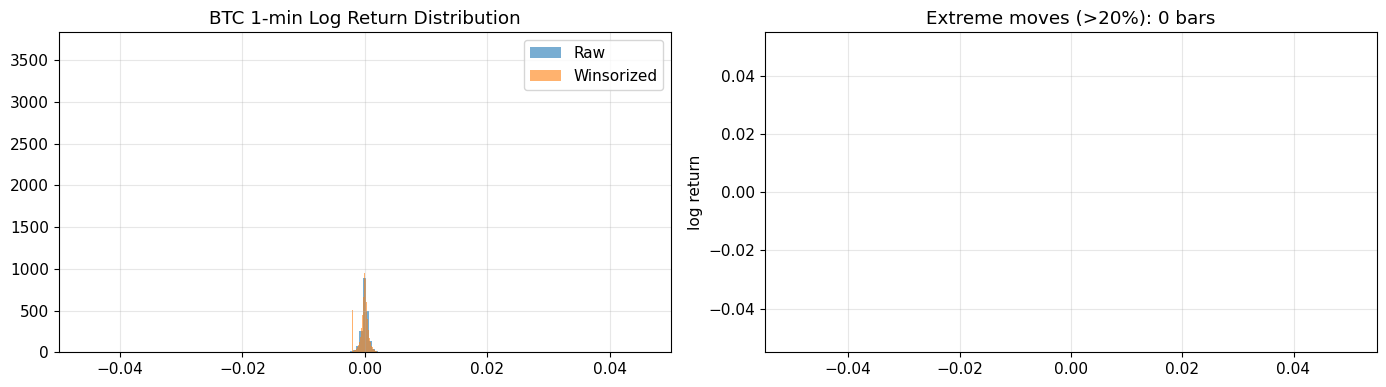

Extreme moves to review manually: 0


In [10]:
symbol = 'BTCUSDT'
df_btc = pd.read_parquet(raw_dir / 'crypto' / f'crypto_1m_{symbol}.parquet')
log_ret = np.log(df_btc['close'] / df_btc['close'].shift(1)).dropna()

# Raw stats
print(f'BTC log returns: mean={log_ret.mean():.6f}, std={log_ret.std():.6f}')
print(f'  skewness={log_ret.skew():.3f}, kurtosis={log_ret.kurtosis():.3f}')
print(f'  1st pct={log_ret.quantile(0.01):.4f}, 99th pct={log_ret.quantile(0.99):.4f}')

# Winsorize
log_ret_w = pd.Series(
    winsorize(log_ret.values, limits=[0.01, 0.01]),
    index=log_ret.index
)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].hist(log_ret, bins=200, alpha=0.6, label='Raw', density=True)
axes[0].hist(log_ret_w, bins=200, alpha=0.6, label='Winsorized', density=True)
axes[0].set_xlim(-0.05, 0.05)
axes[0].set_title('BTC 1-min Log Return Distribution')
axes[0].legend()

# Extreme move flag: > 20% in a single bar is likely a data error
extreme = log_ret[log_ret.abs() > 0.20]
axes[1].scatter(extreme.index, extreme.values, s=10, color='red')
axes[1].set_title(f'Extreme moves (>20%): {len(extreme)} bars')
axes[1].set_ylabel('log return')

plt.tight_layout()
fig_dir = Path('../data/figures')
fig_dir.mkdir(parents=True, exist_ok=True)
plt.savefig(fig_dir / 'btc_return_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Extreme moves to review manually: {len(extreme)}')


## 4. Prediction Market Probability Plots

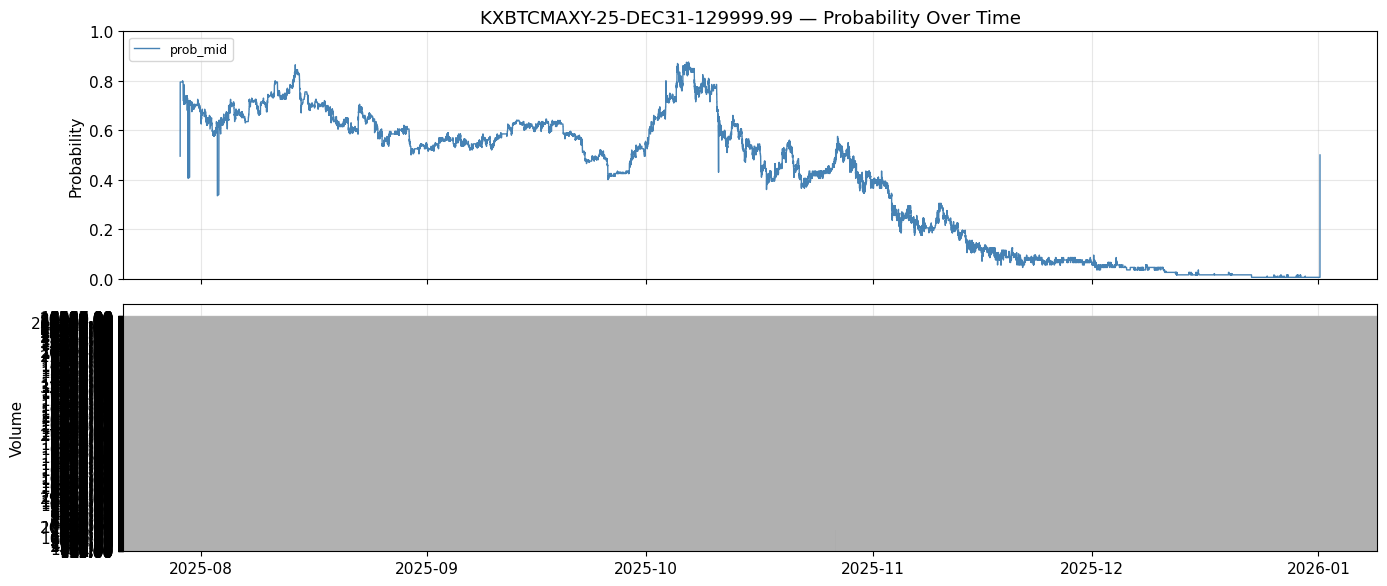

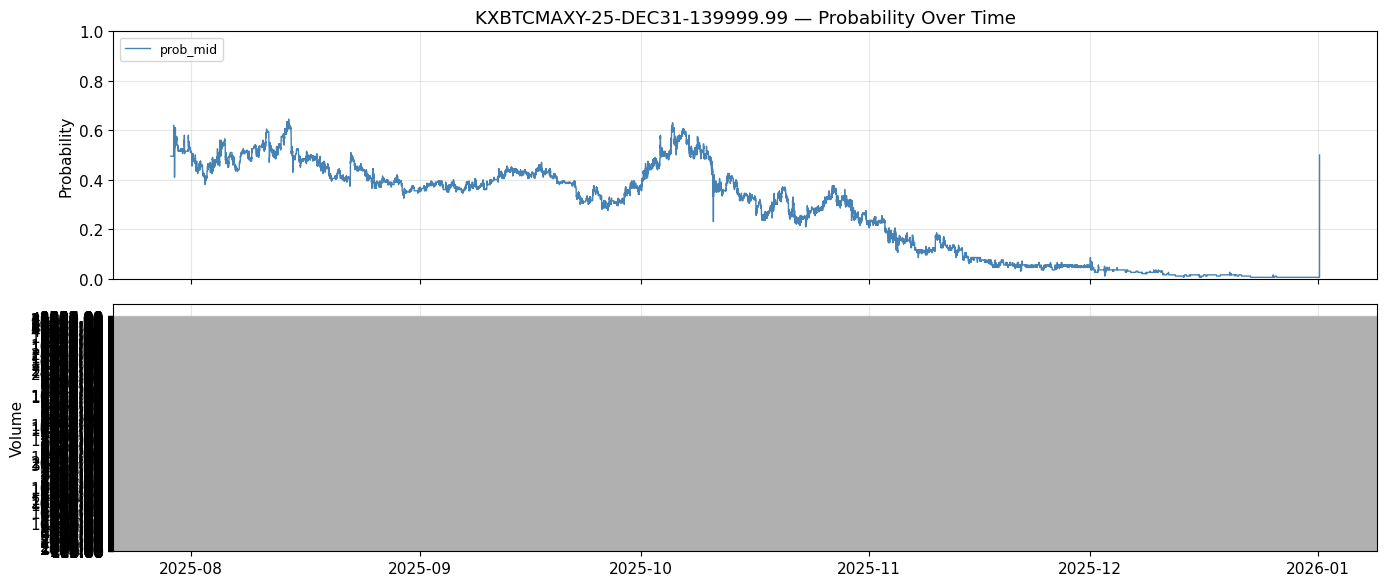

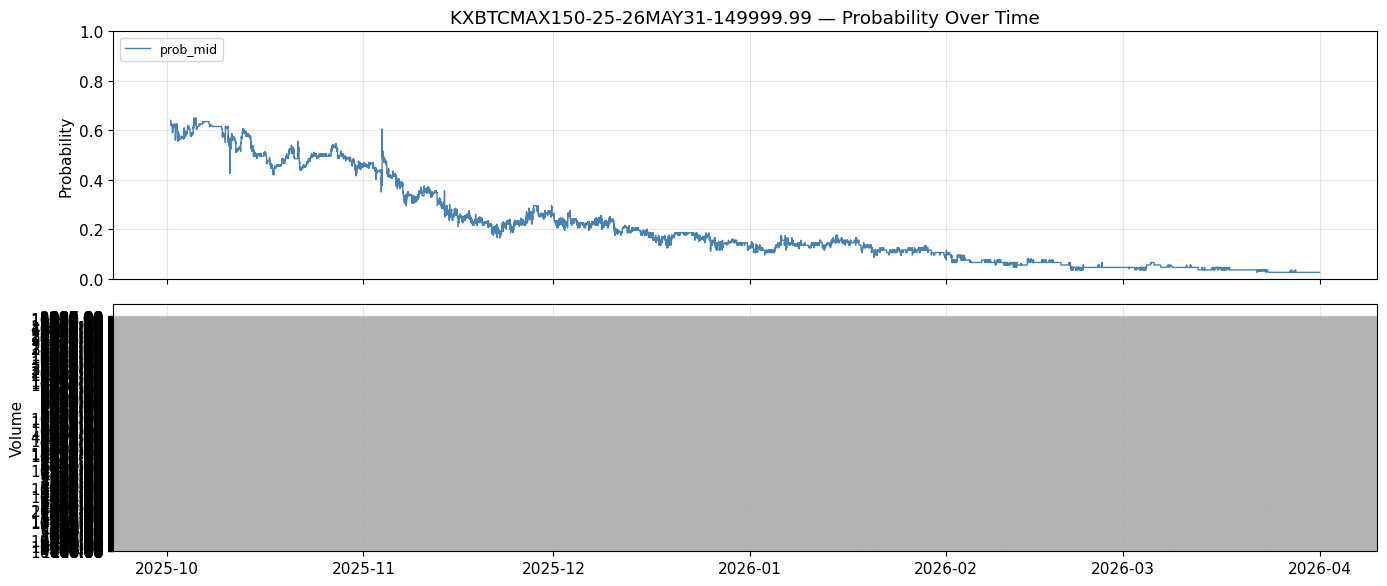

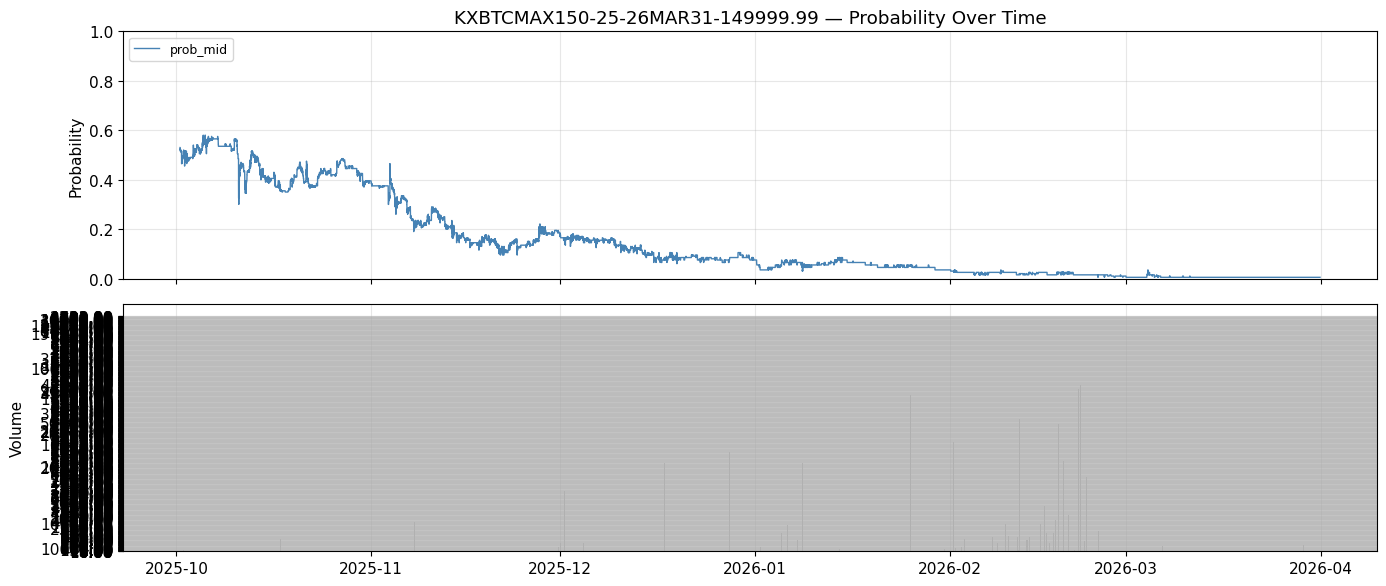

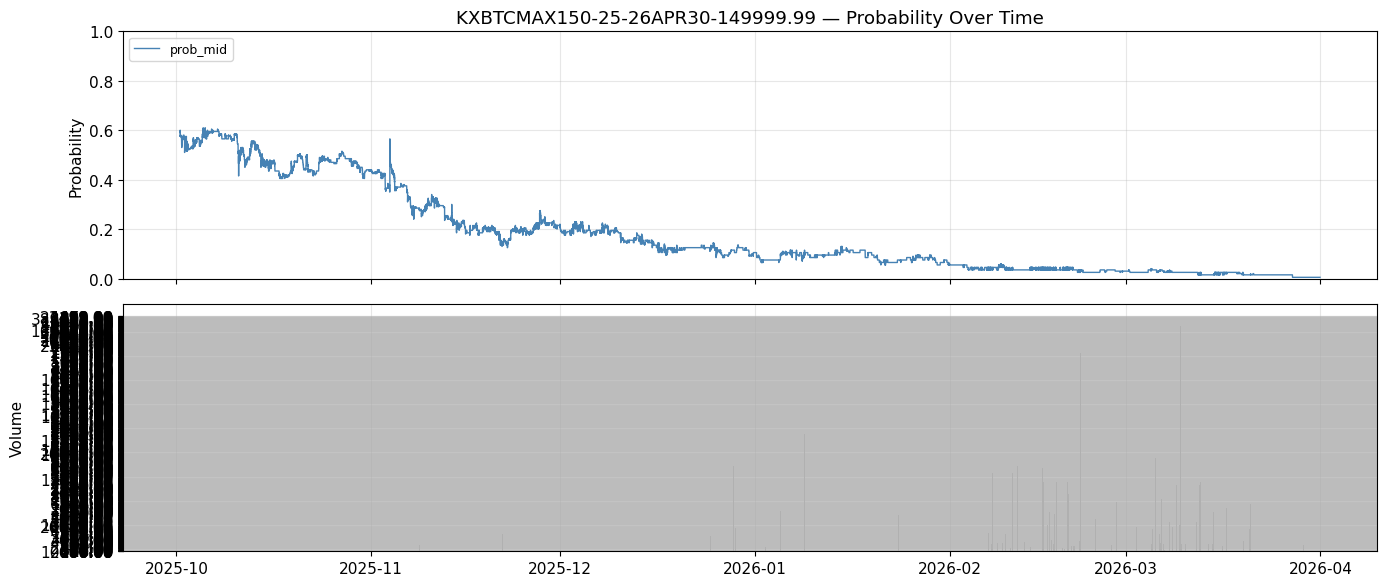

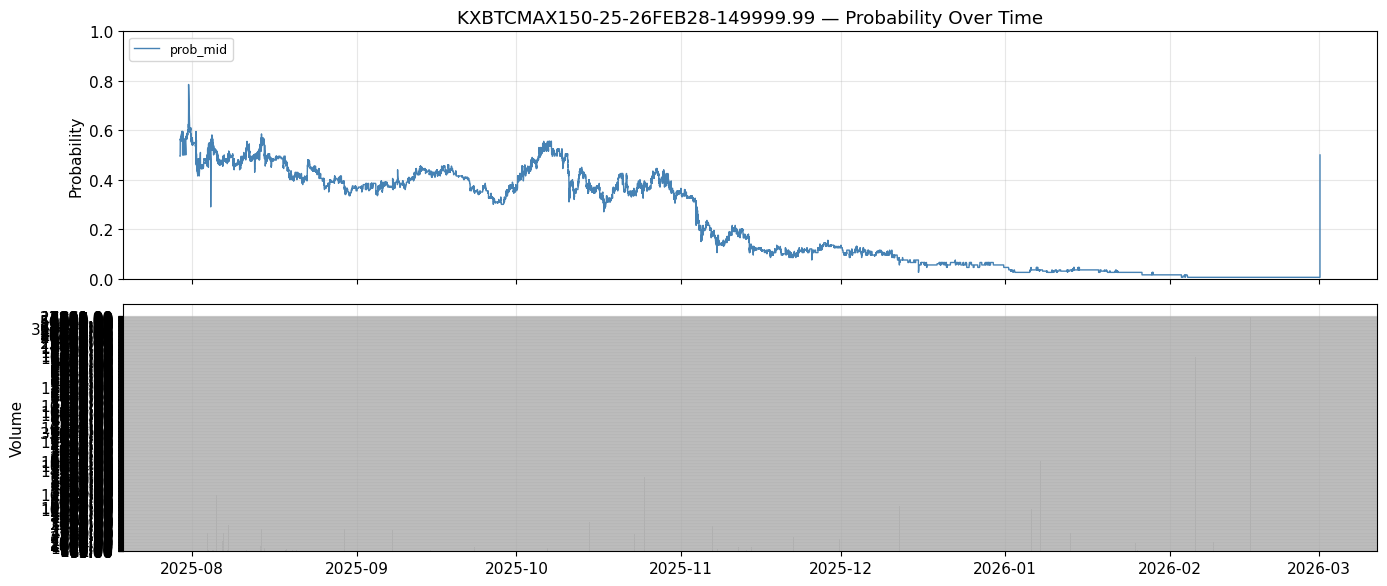

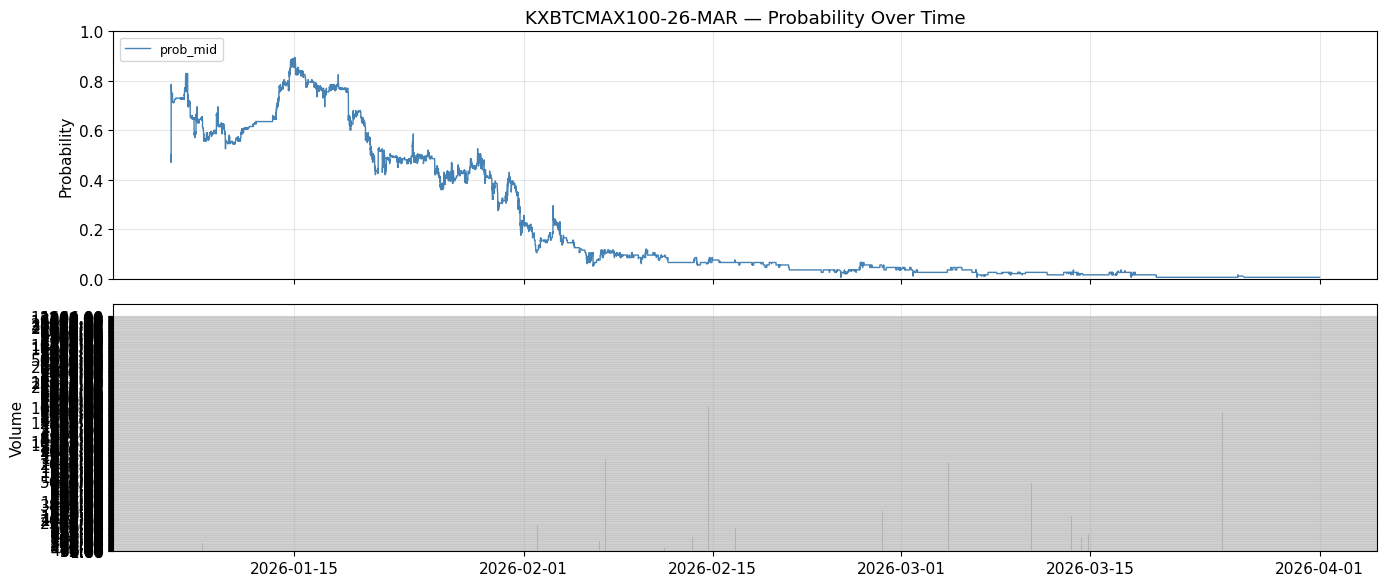

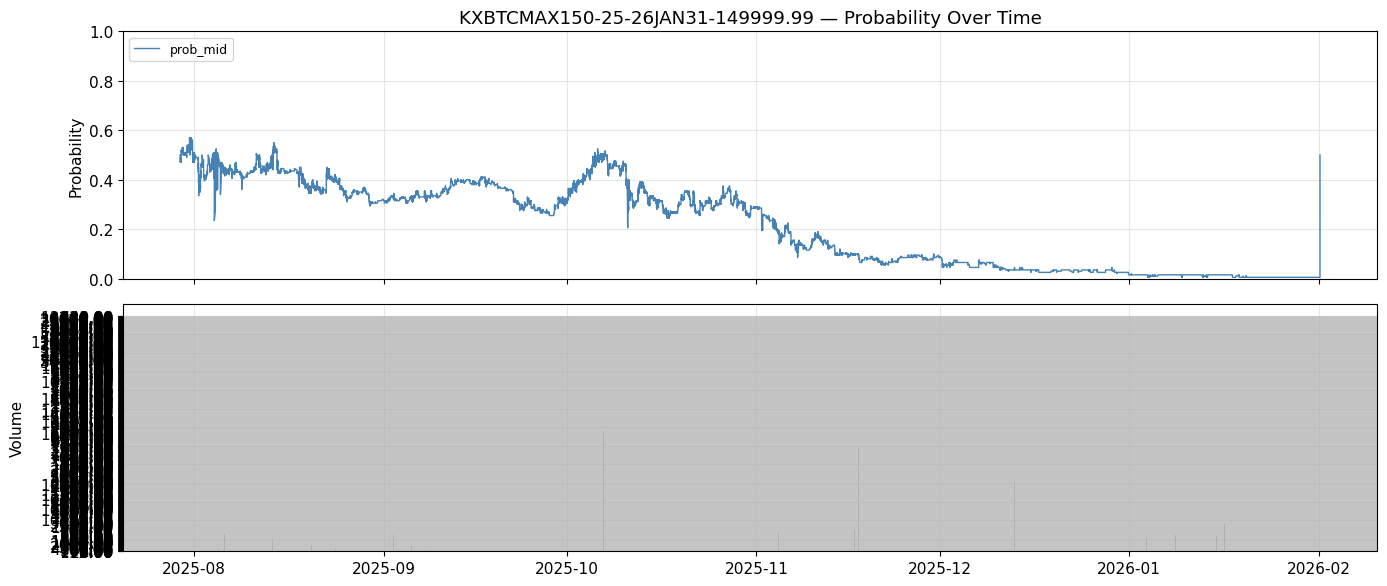

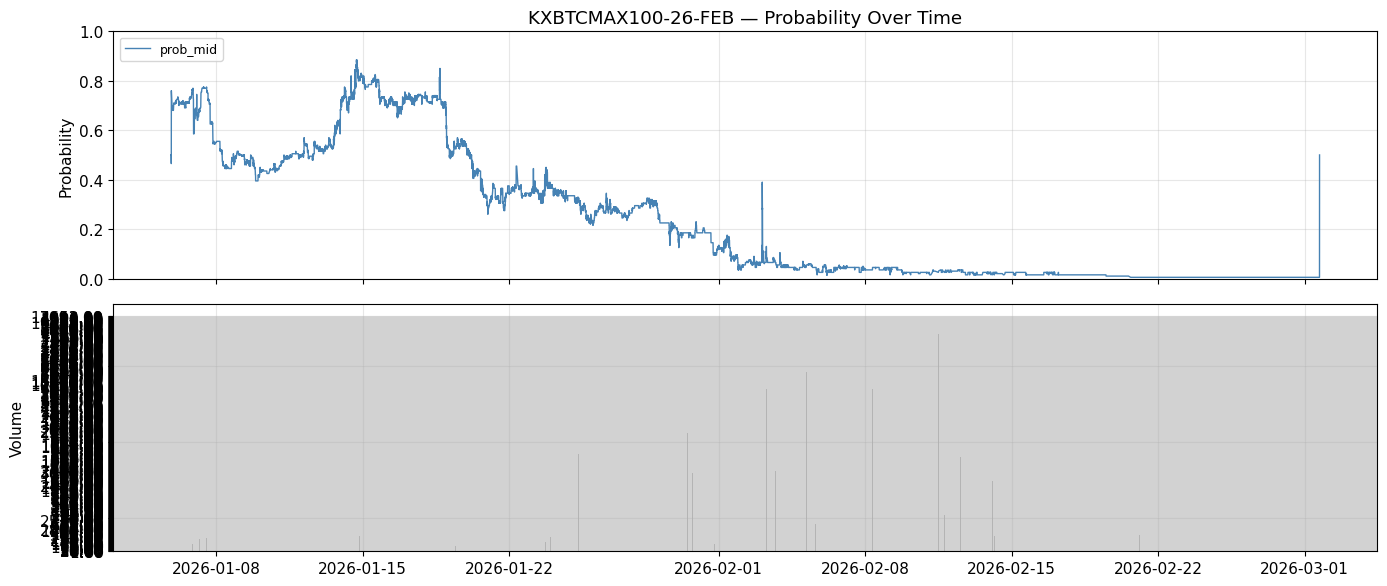

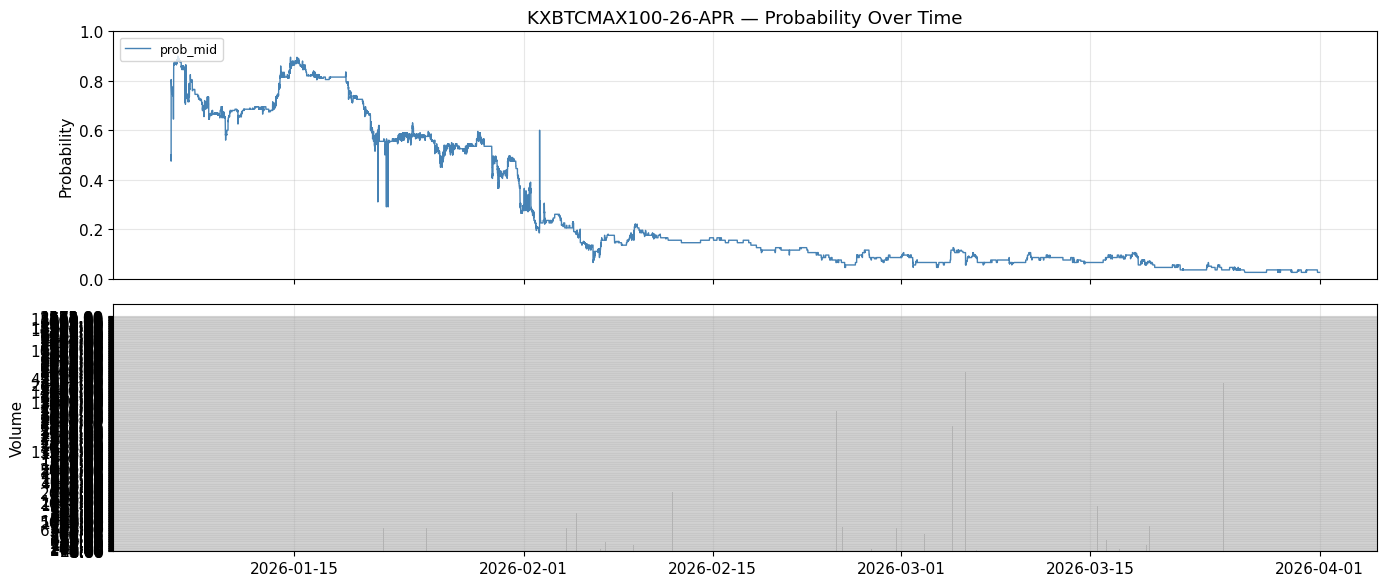

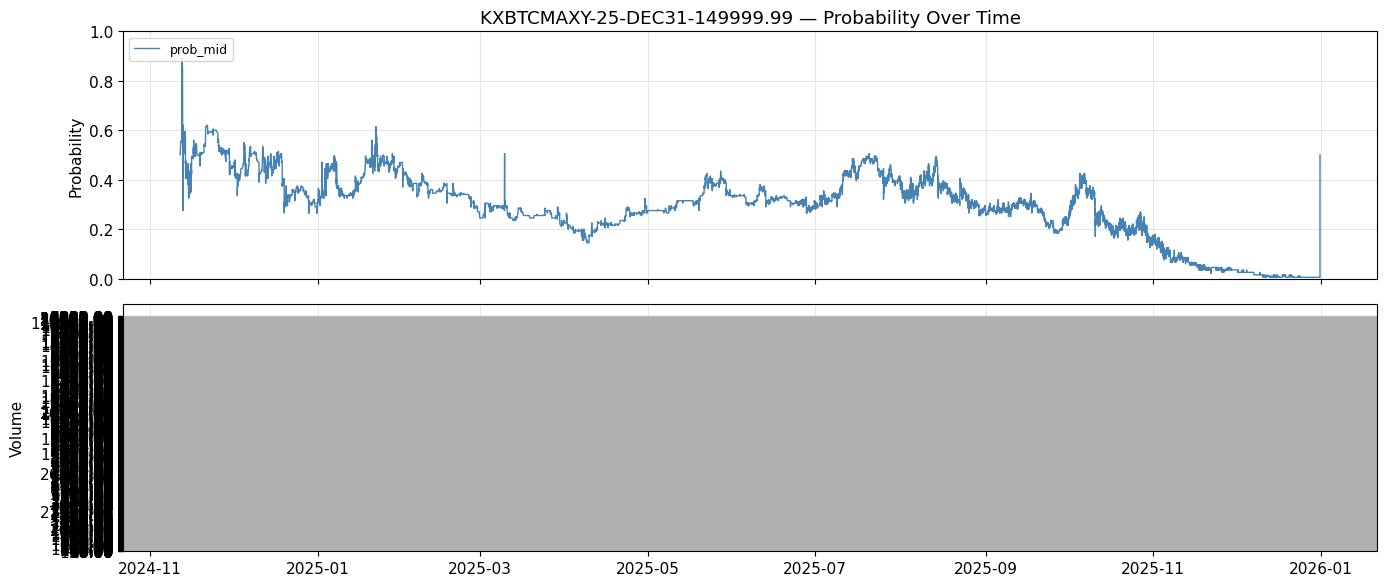

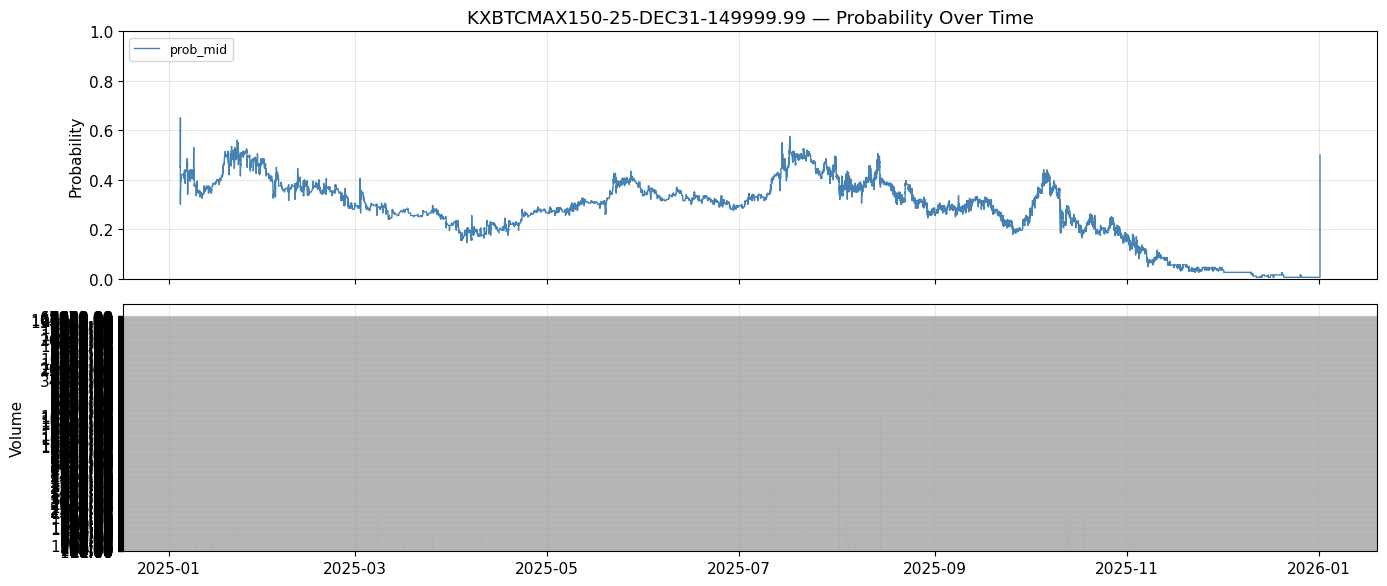

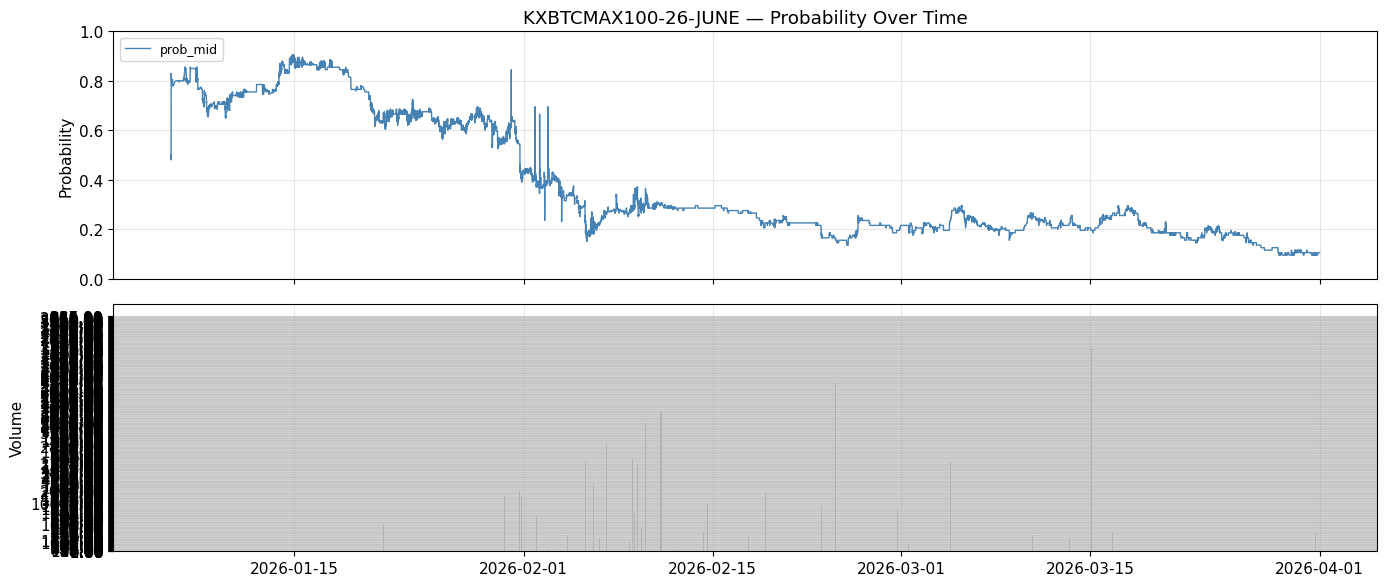

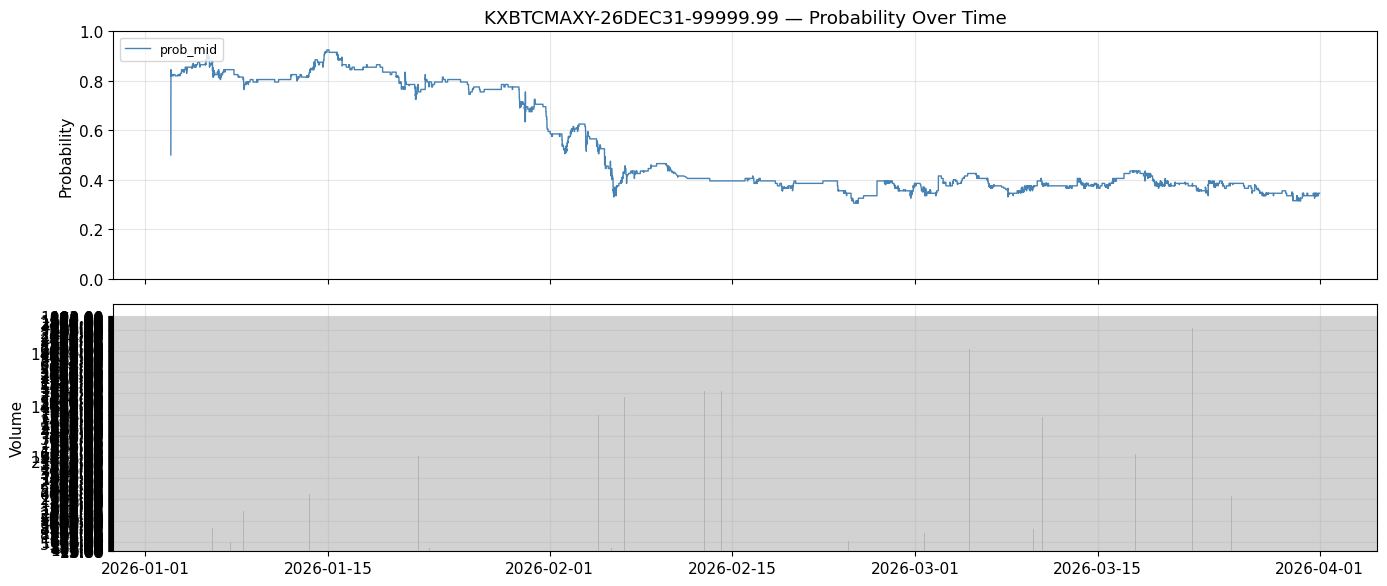

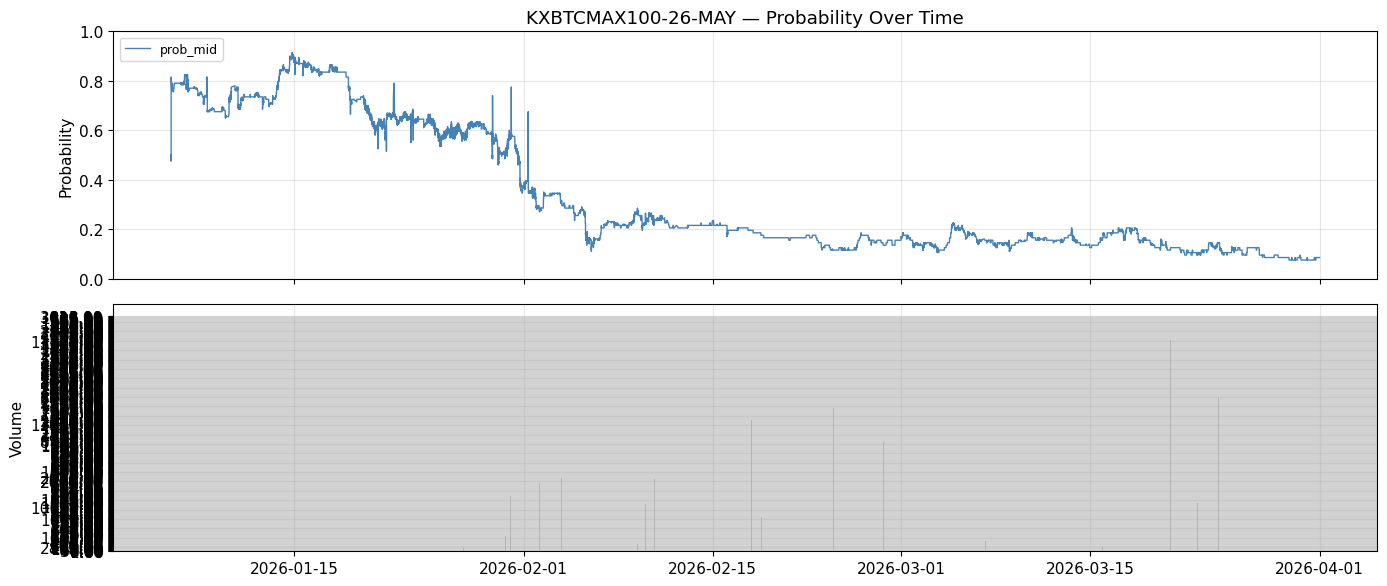

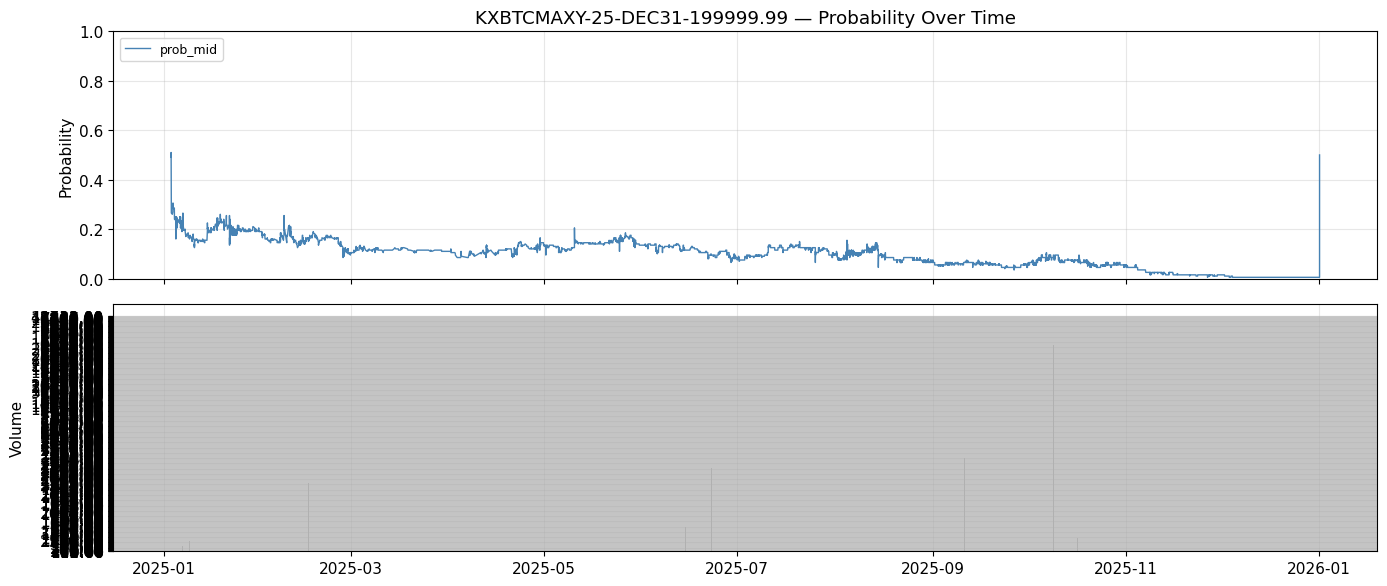

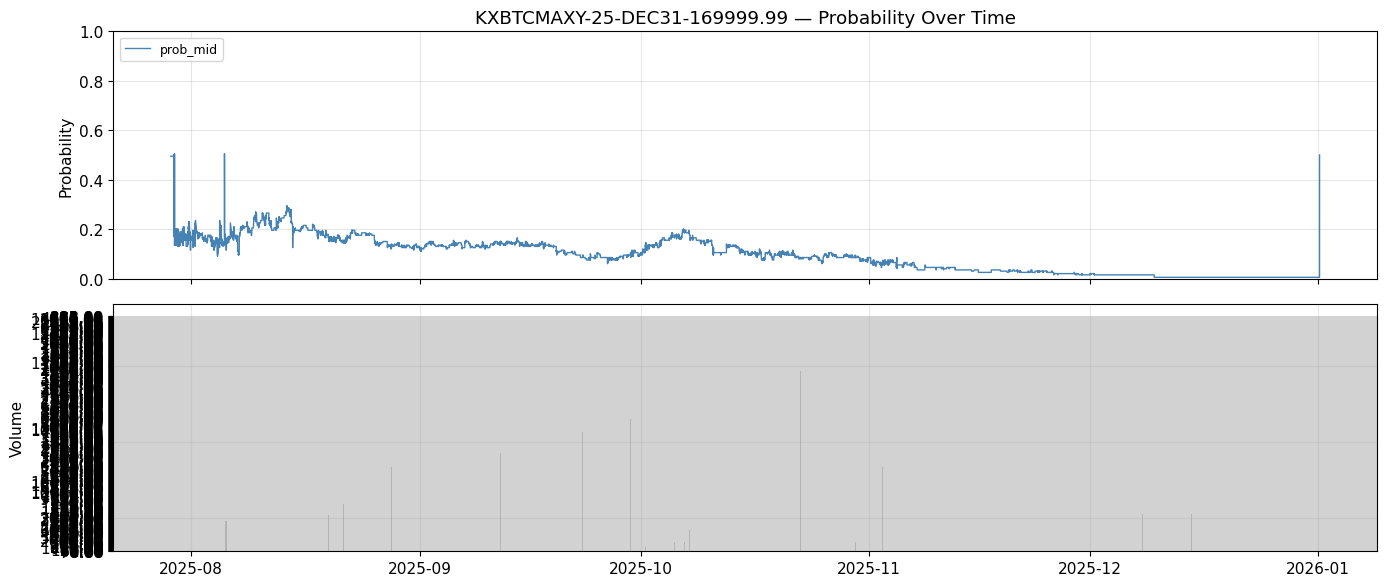

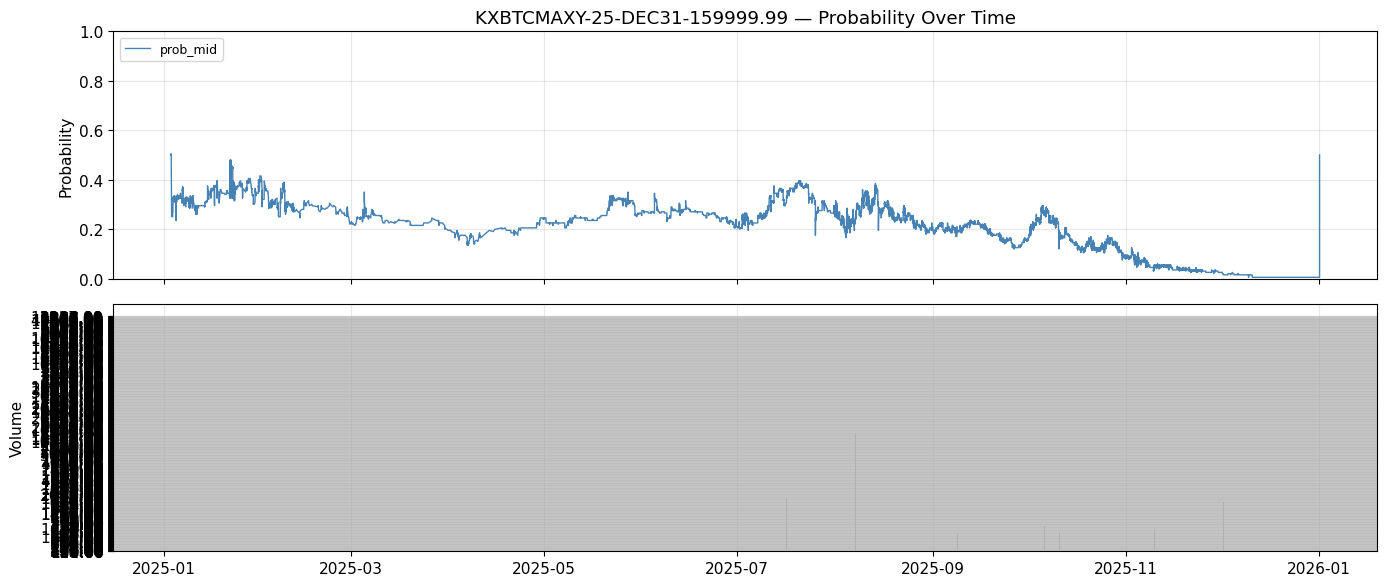

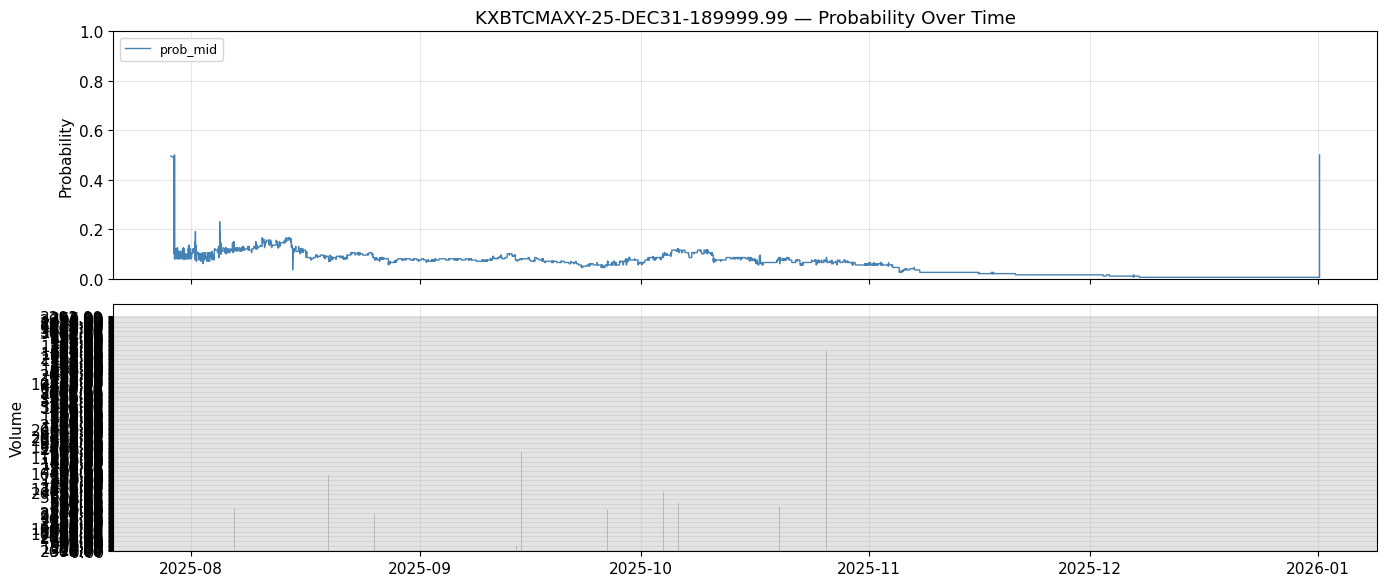

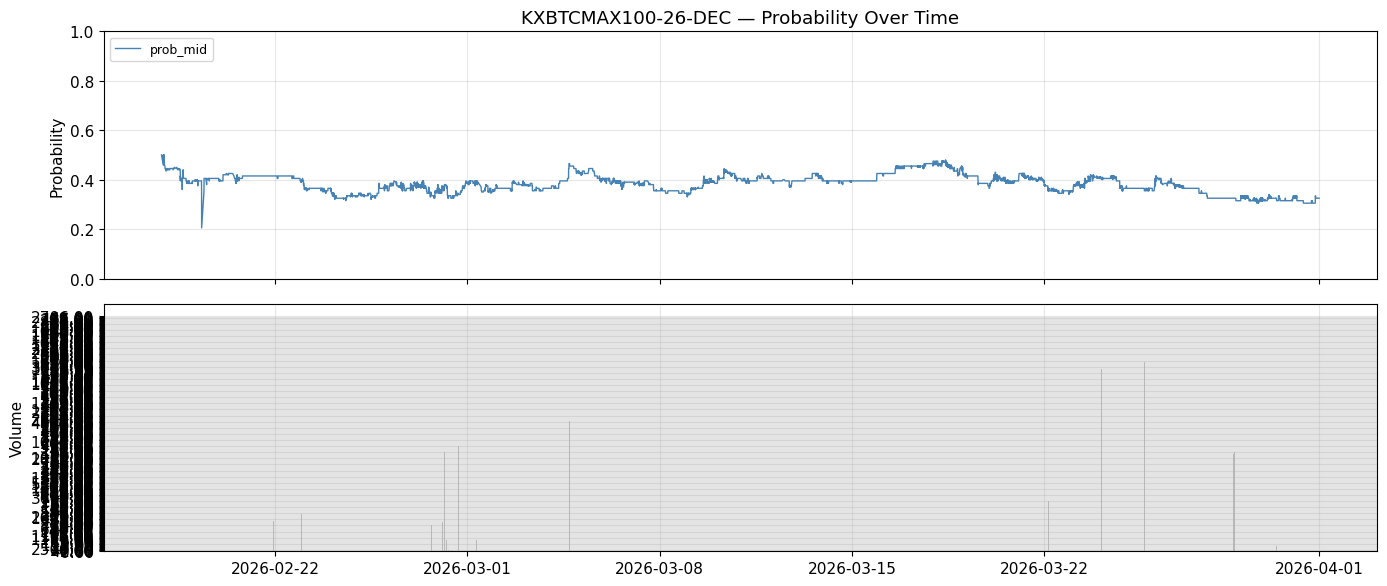

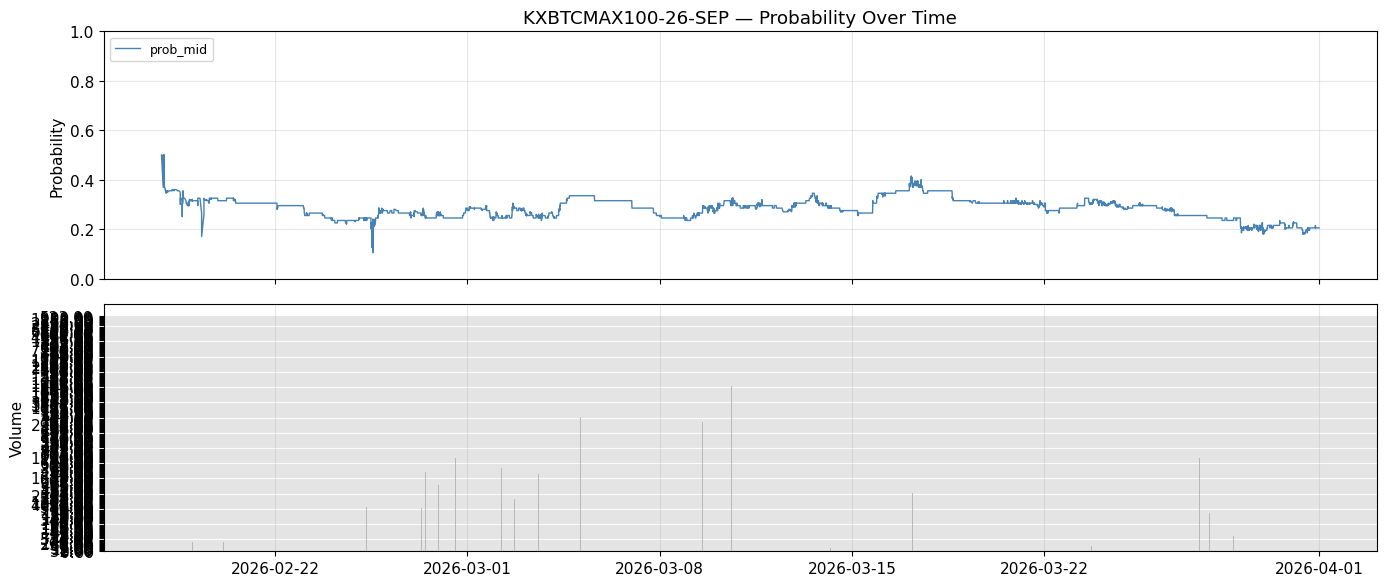

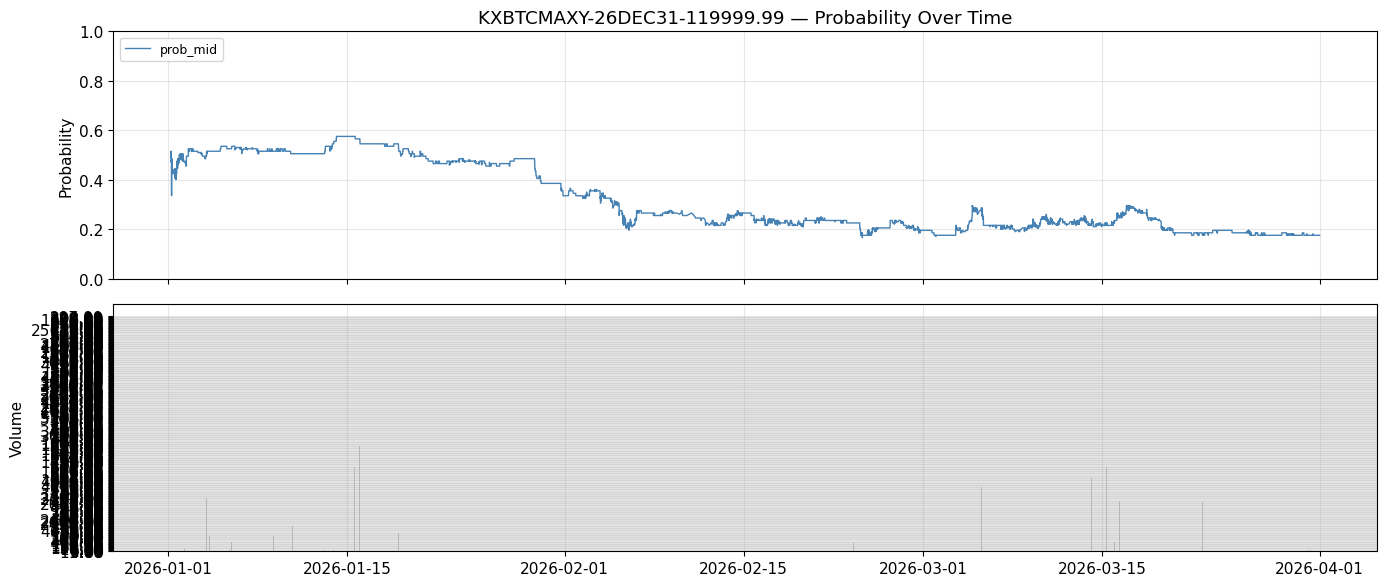

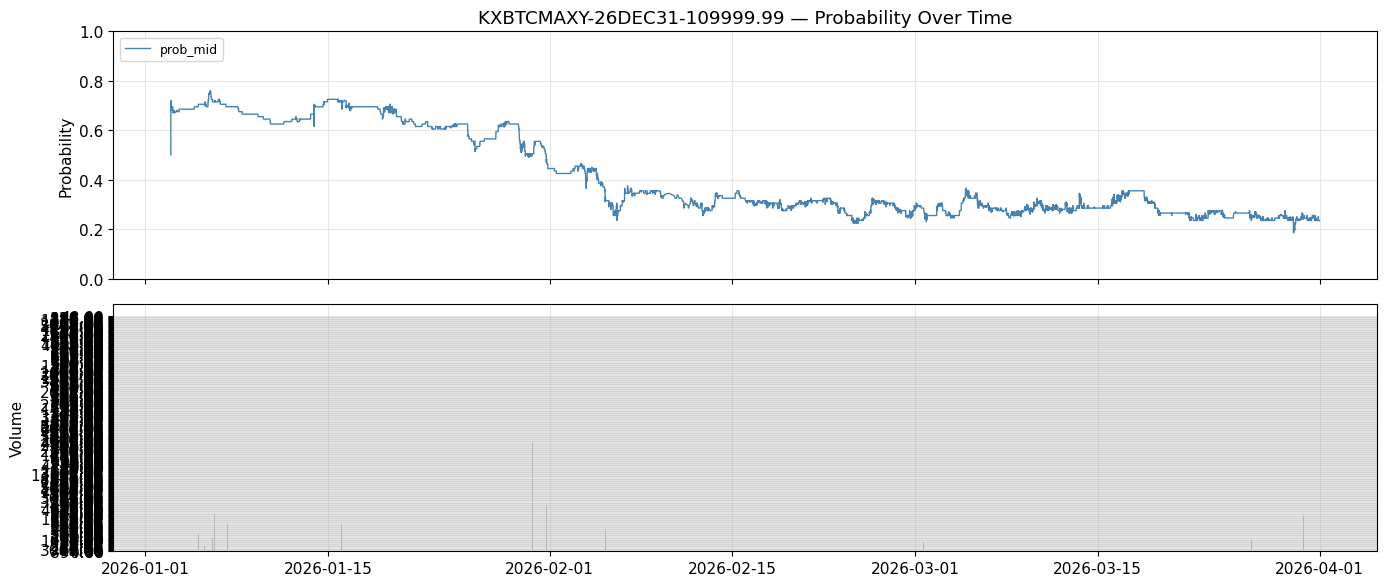

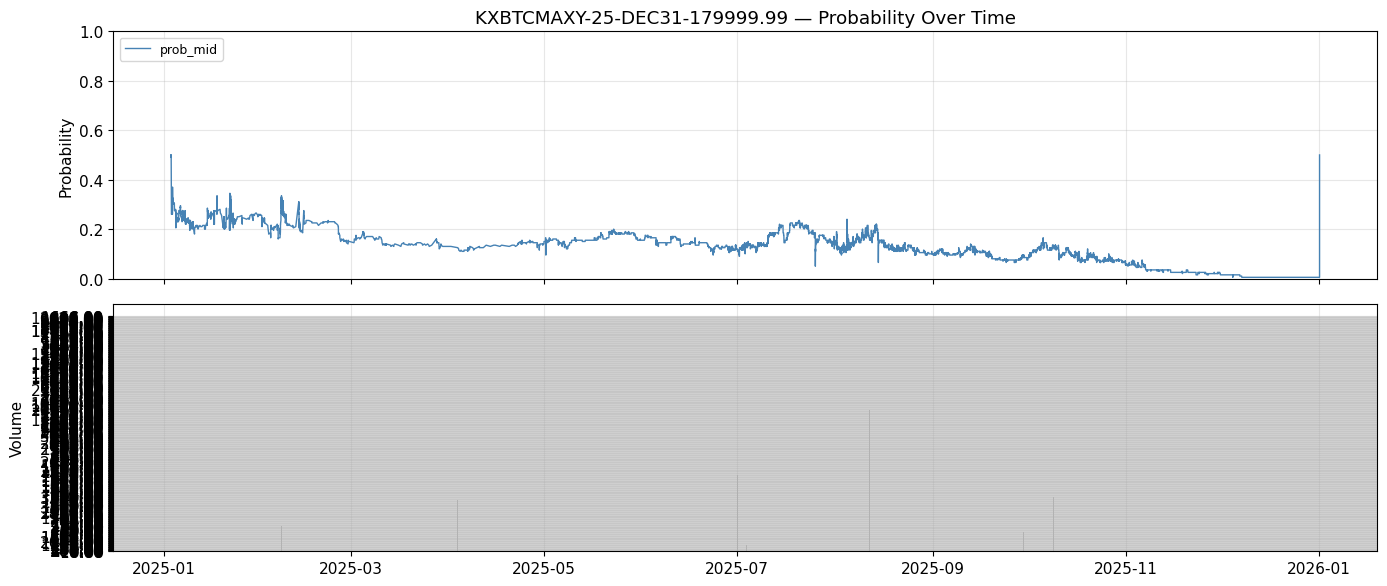

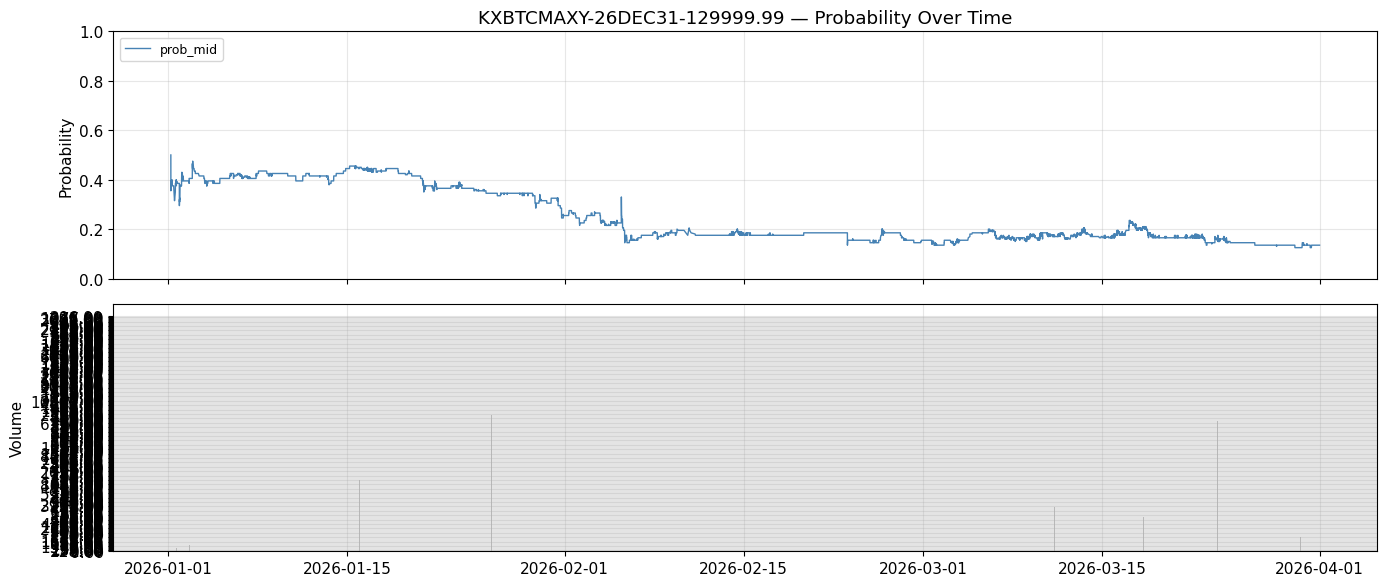

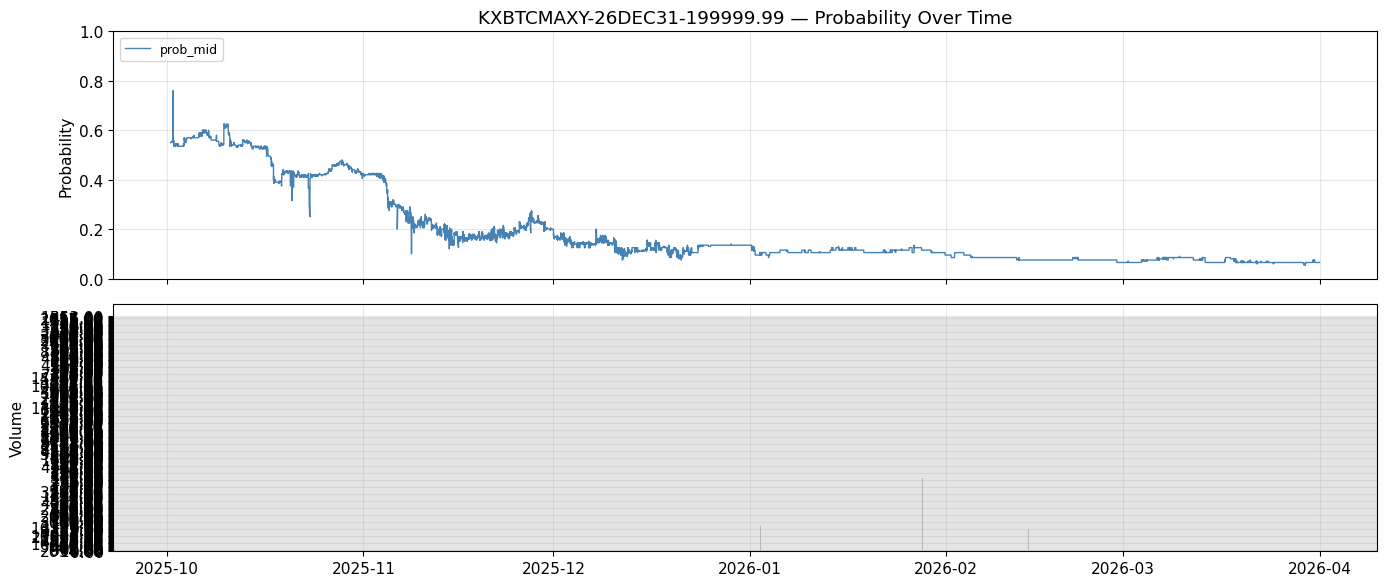

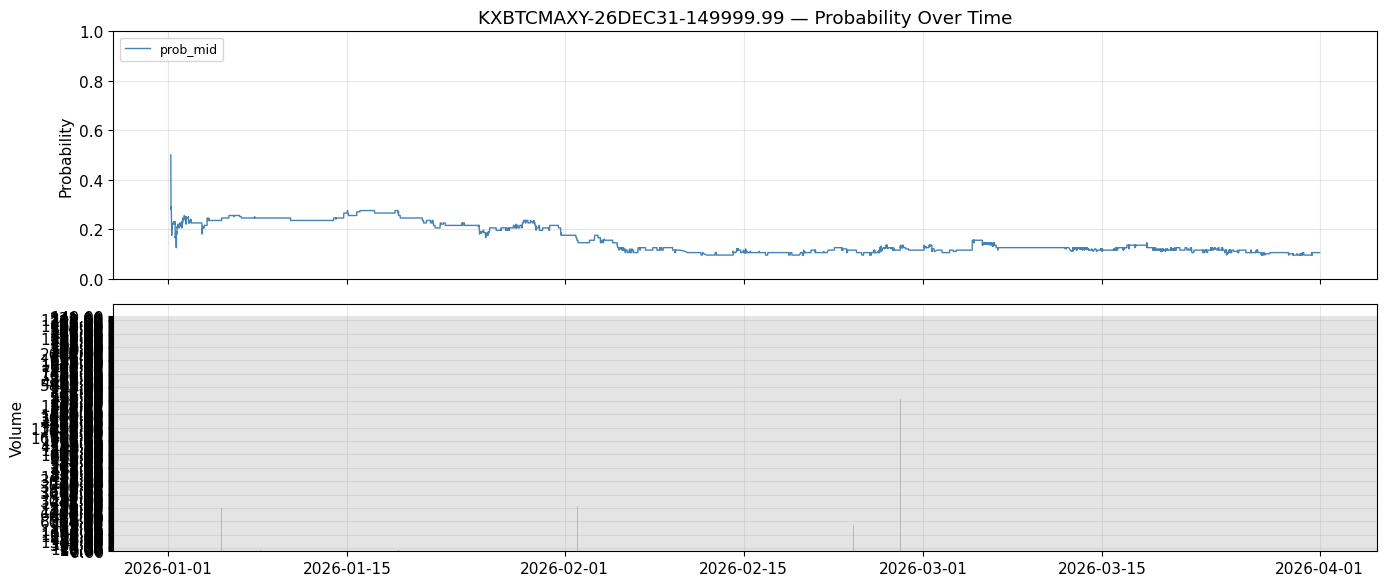

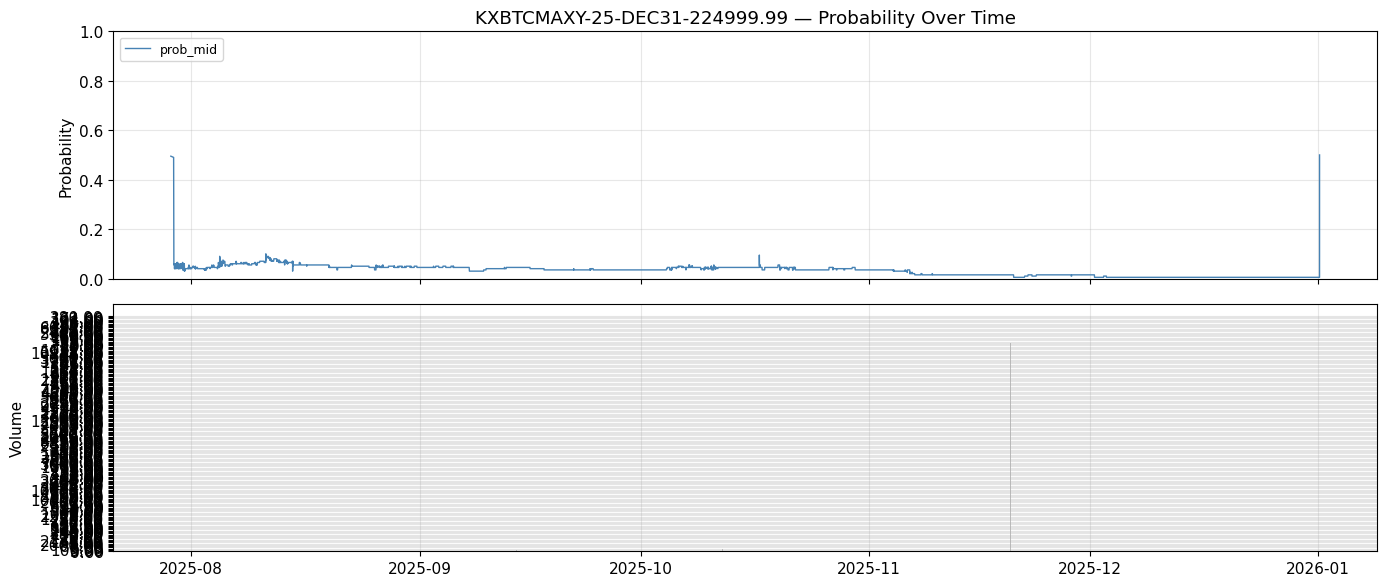

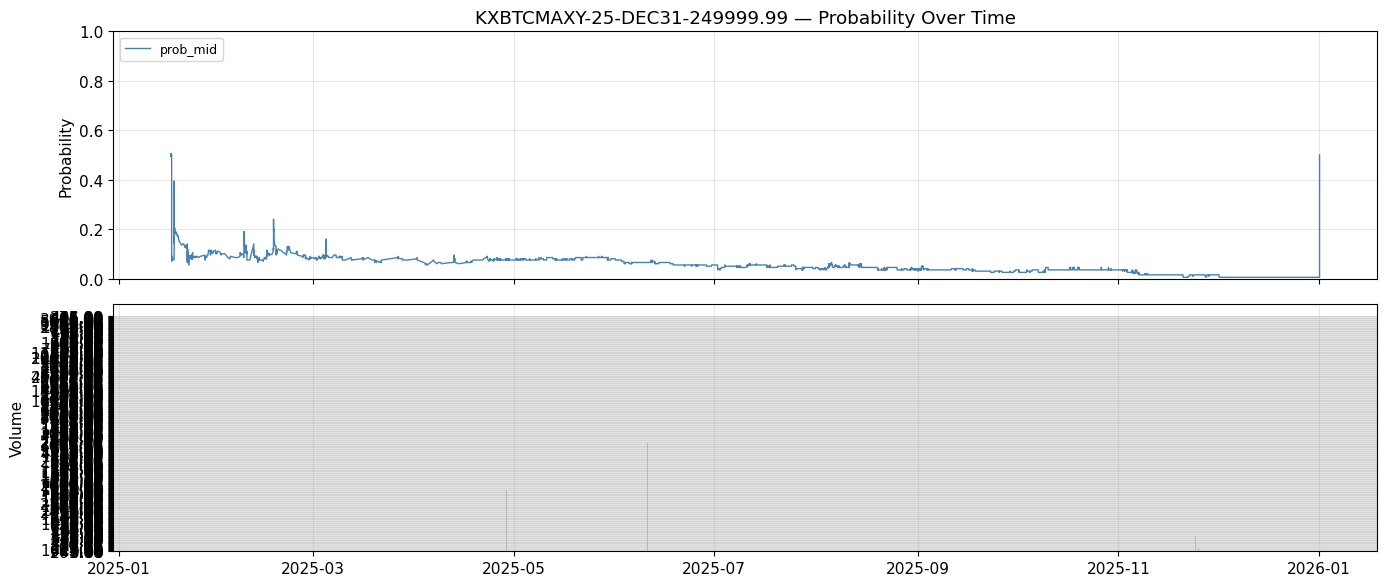

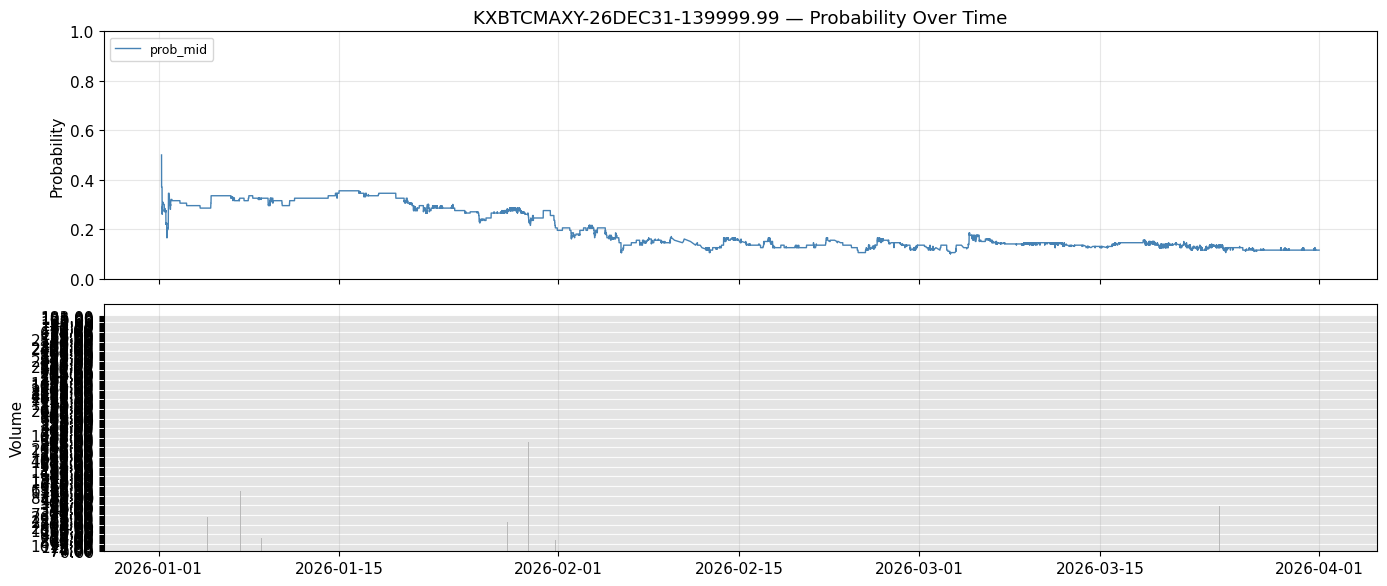

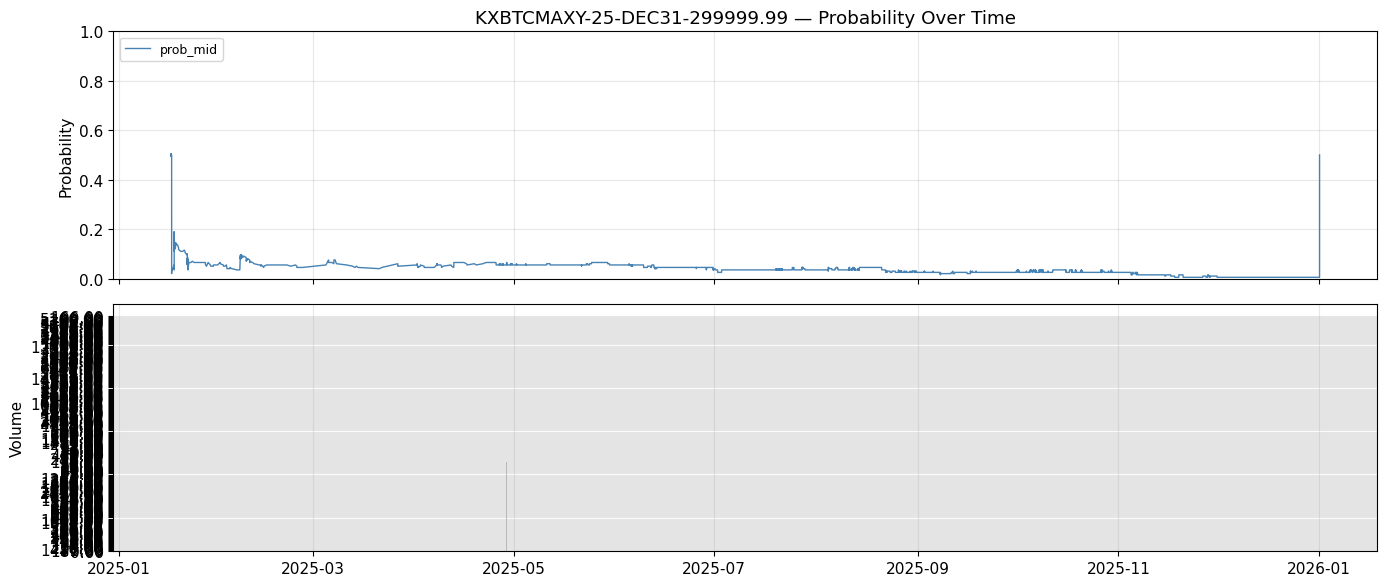

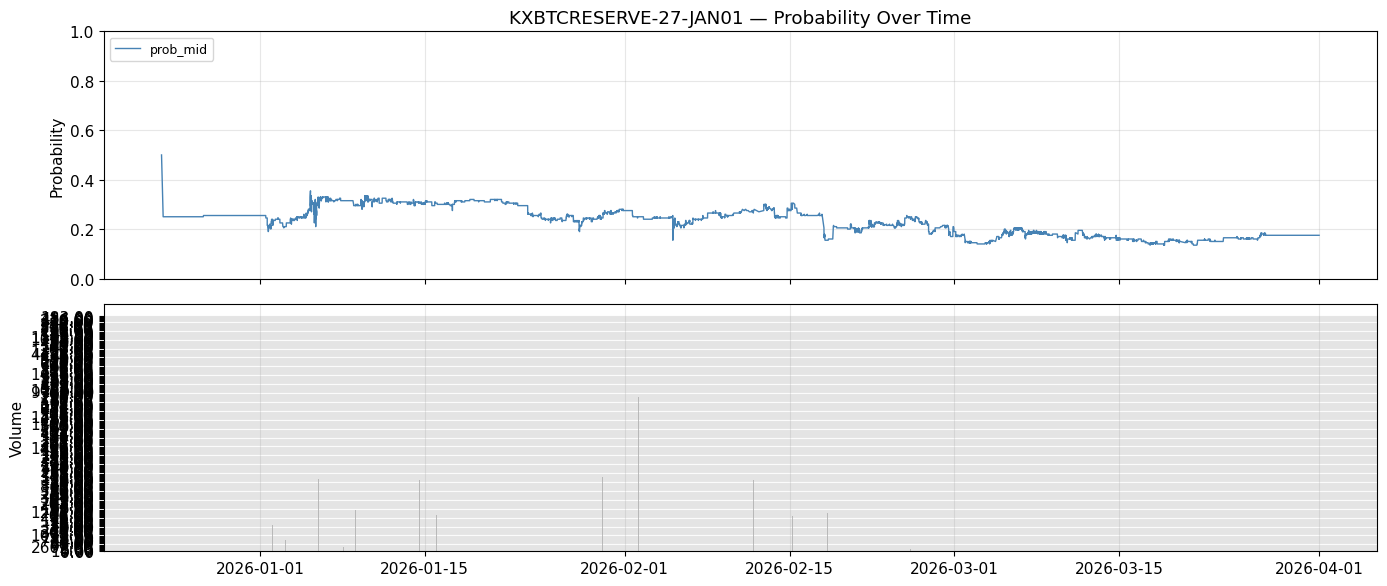

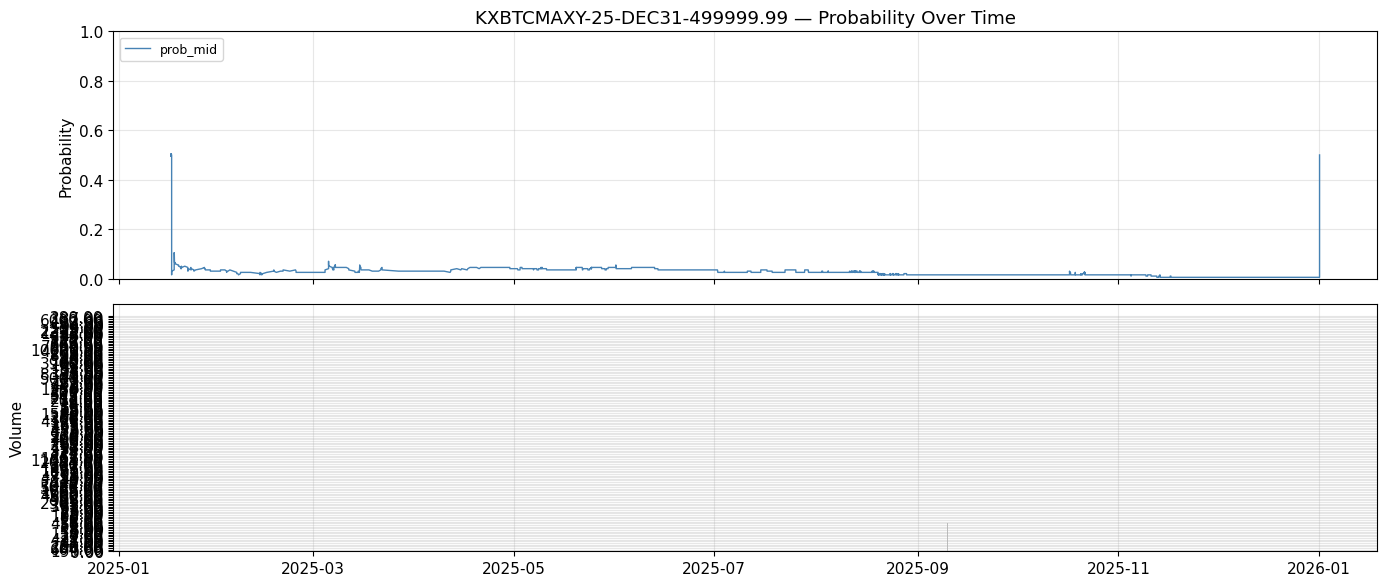

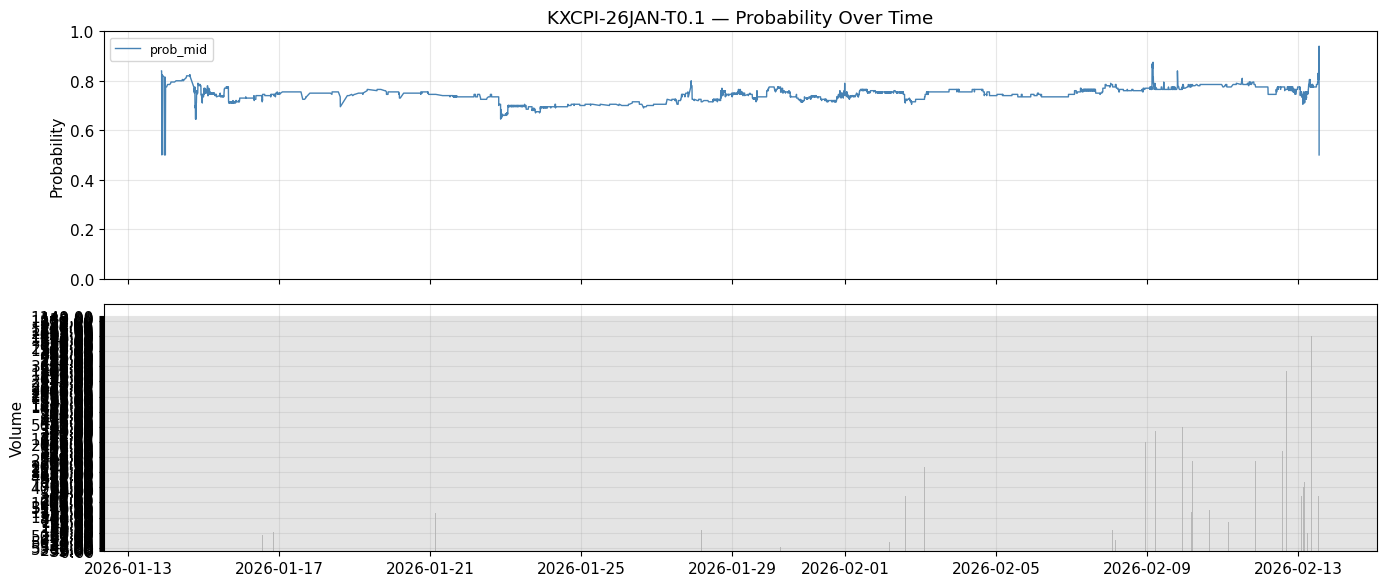

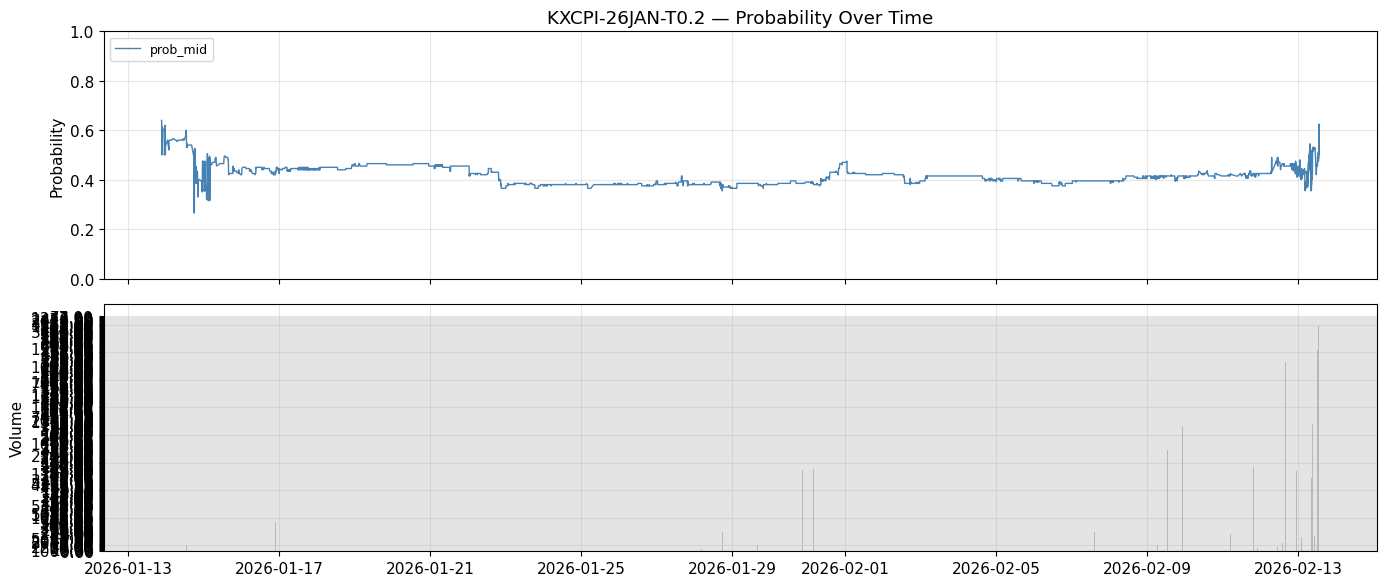

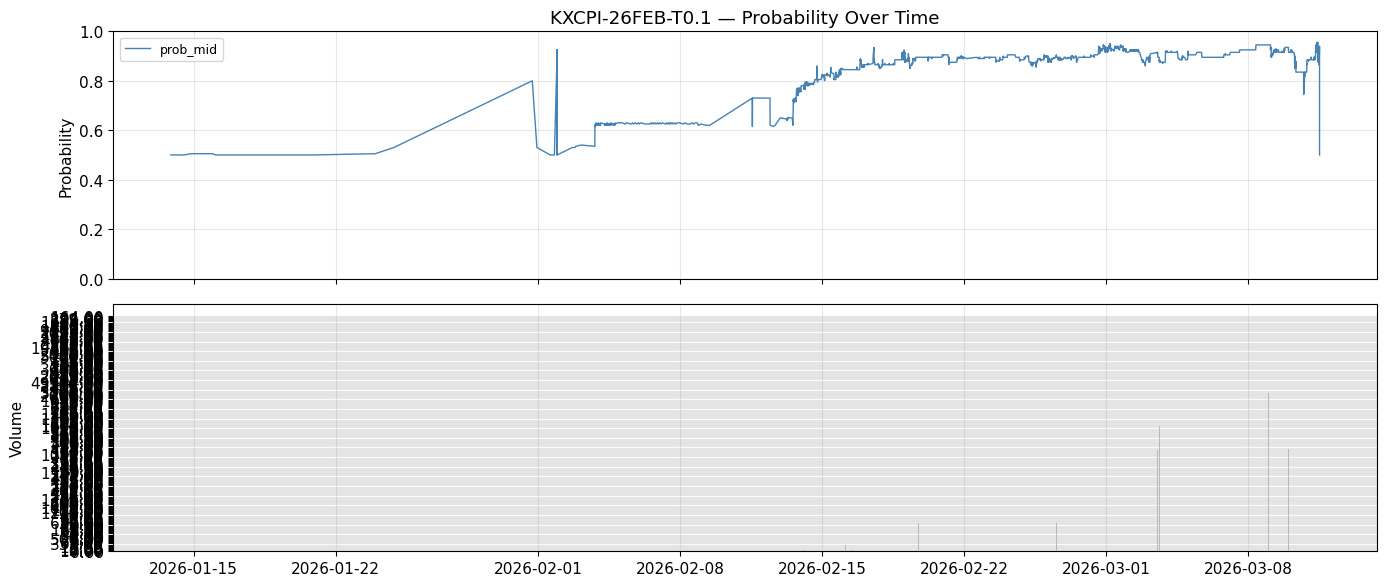

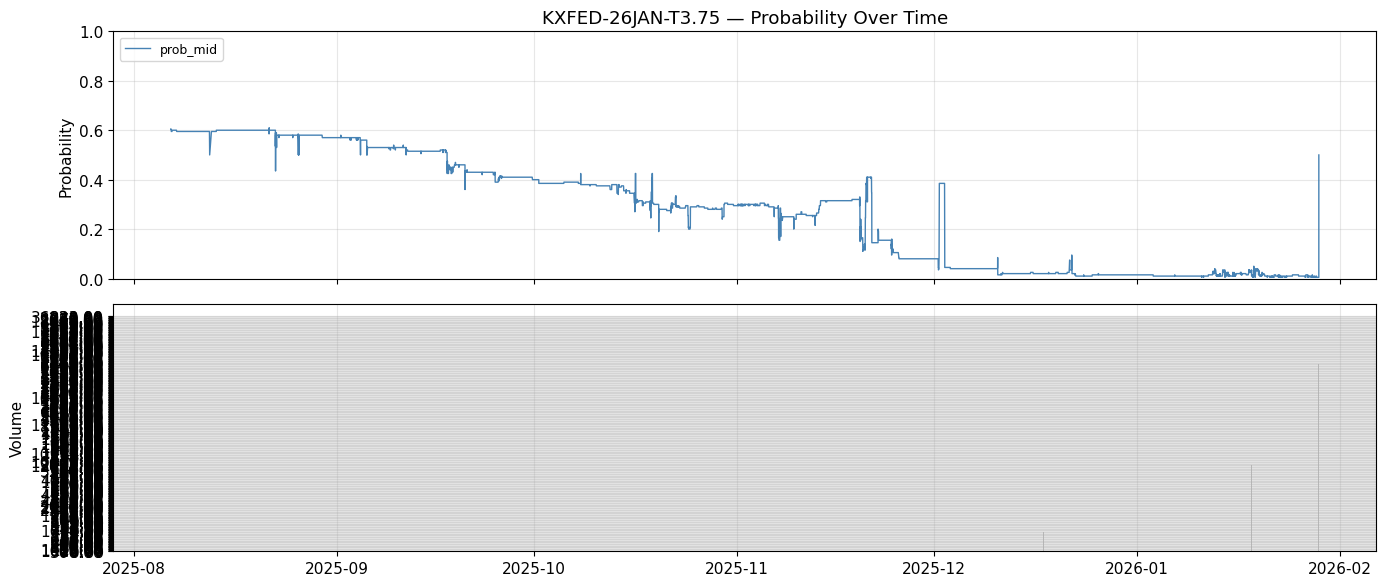

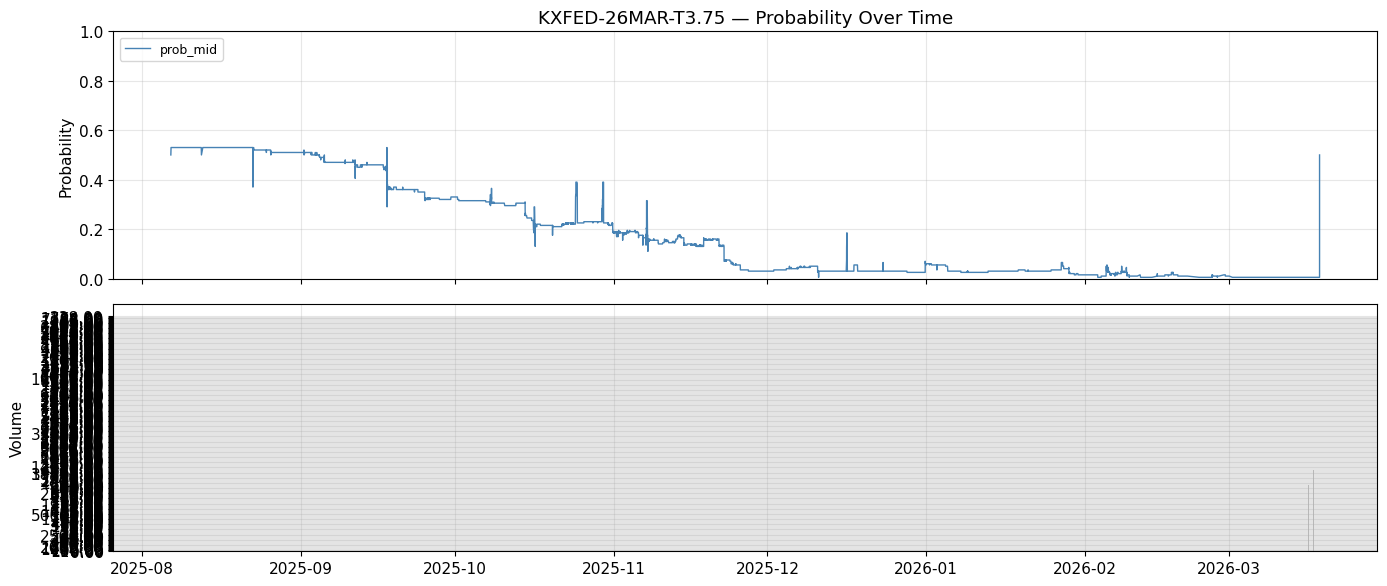

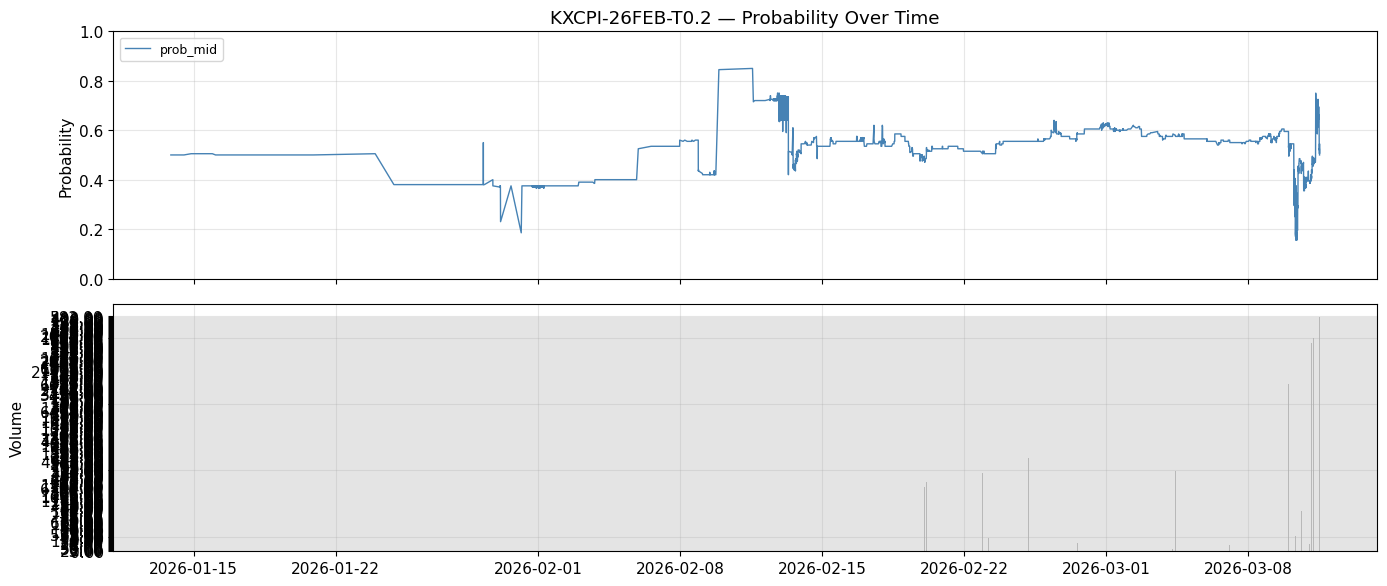

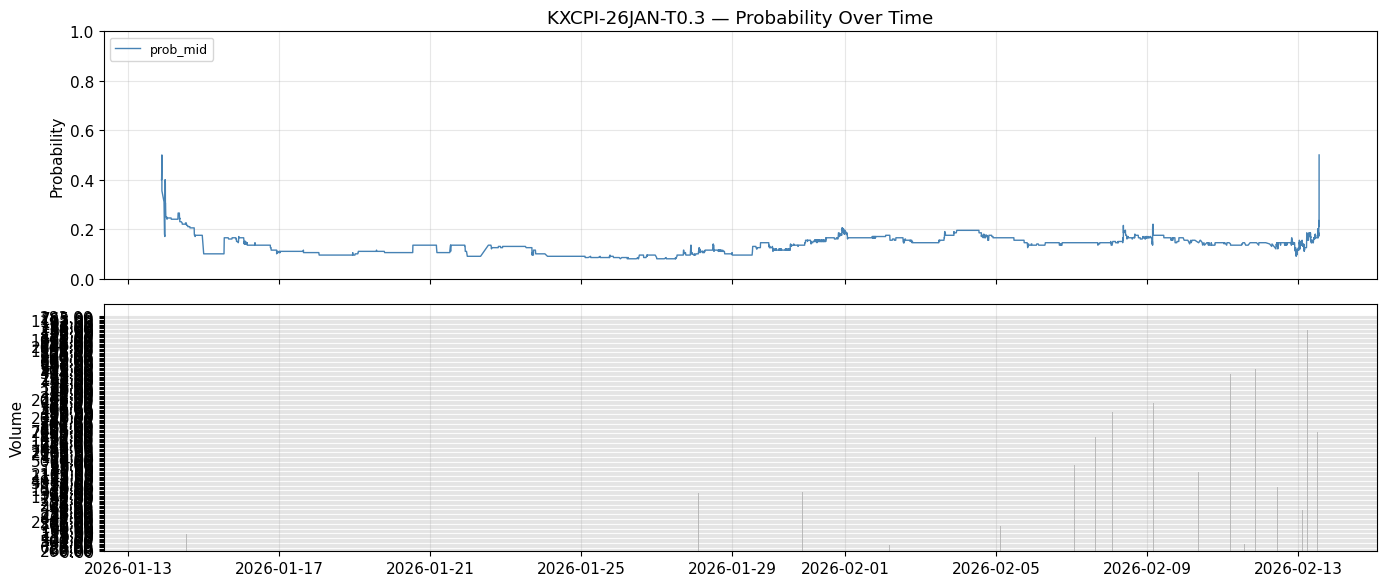

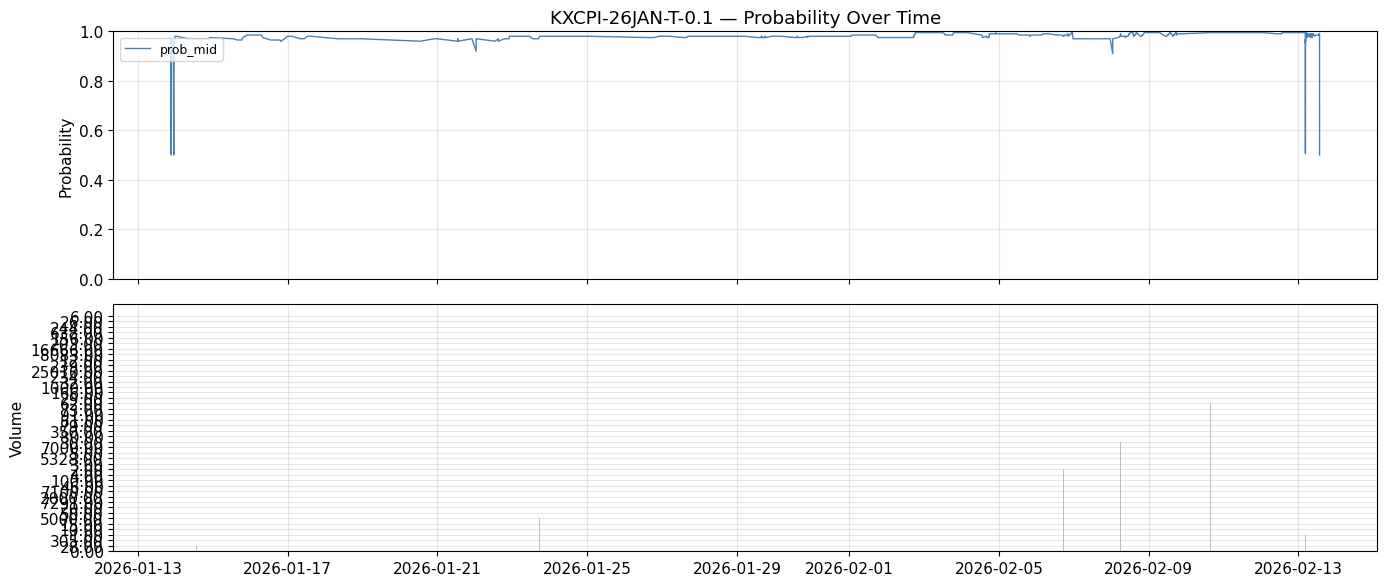

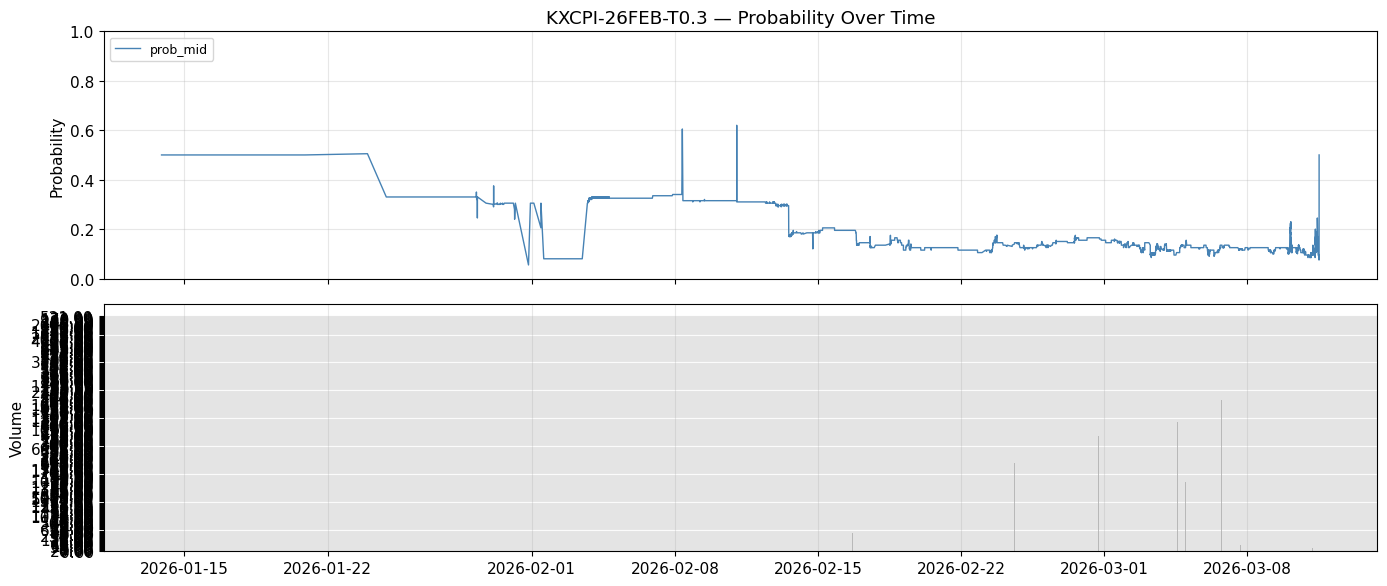

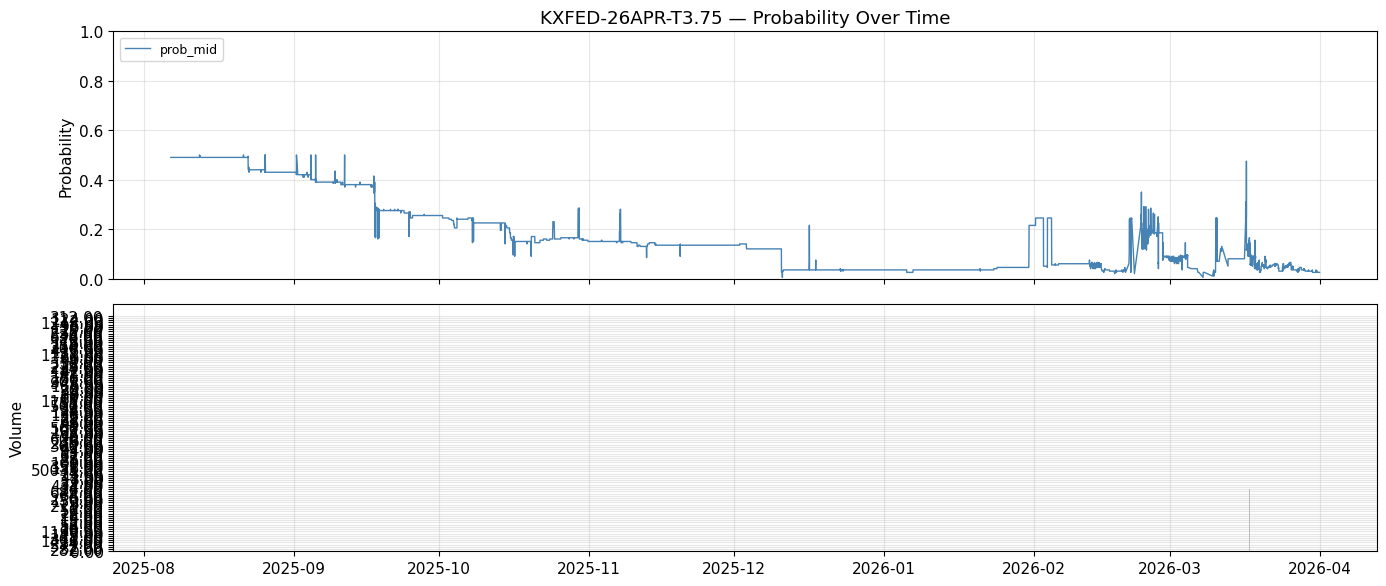

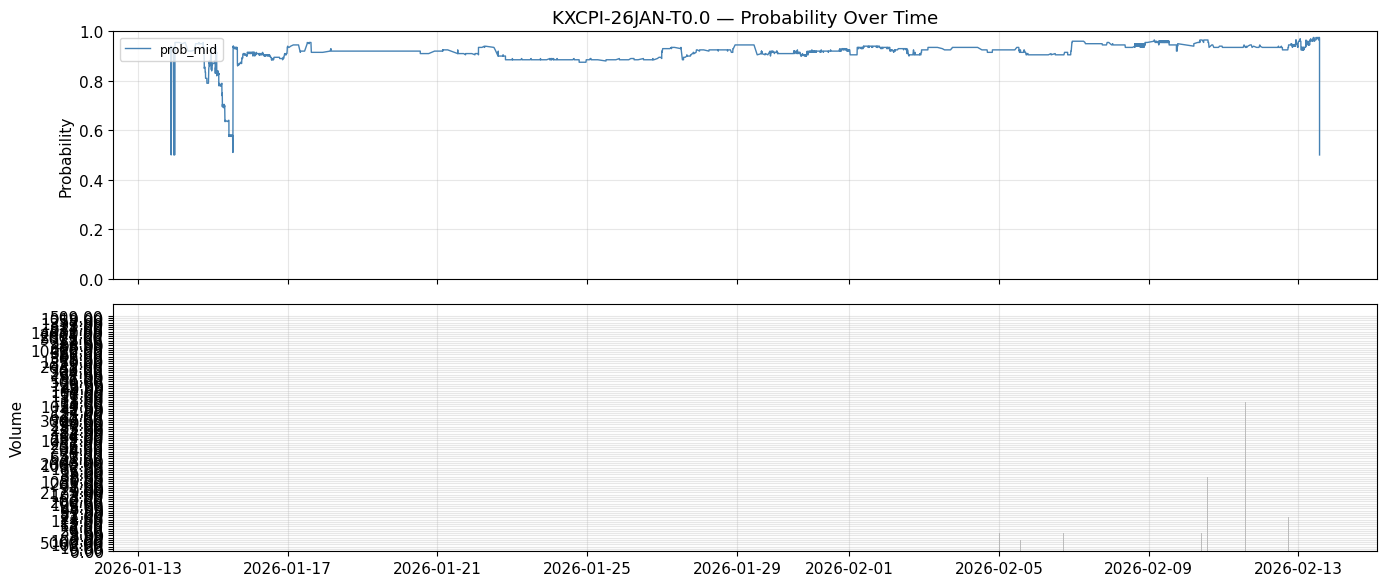

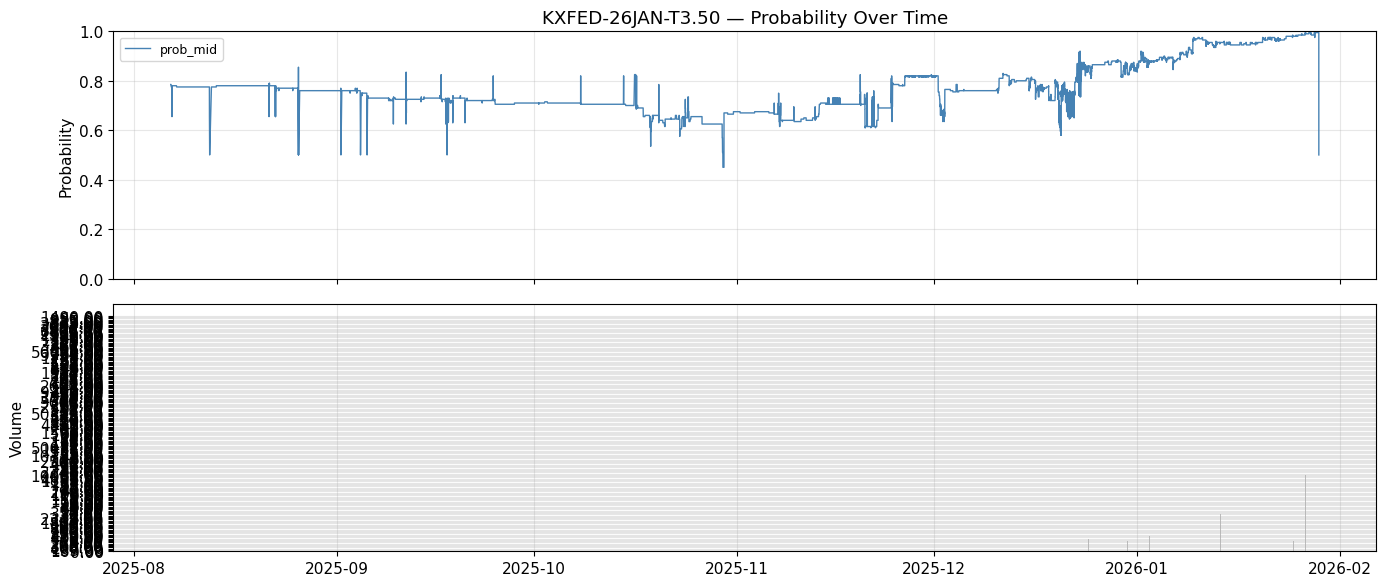

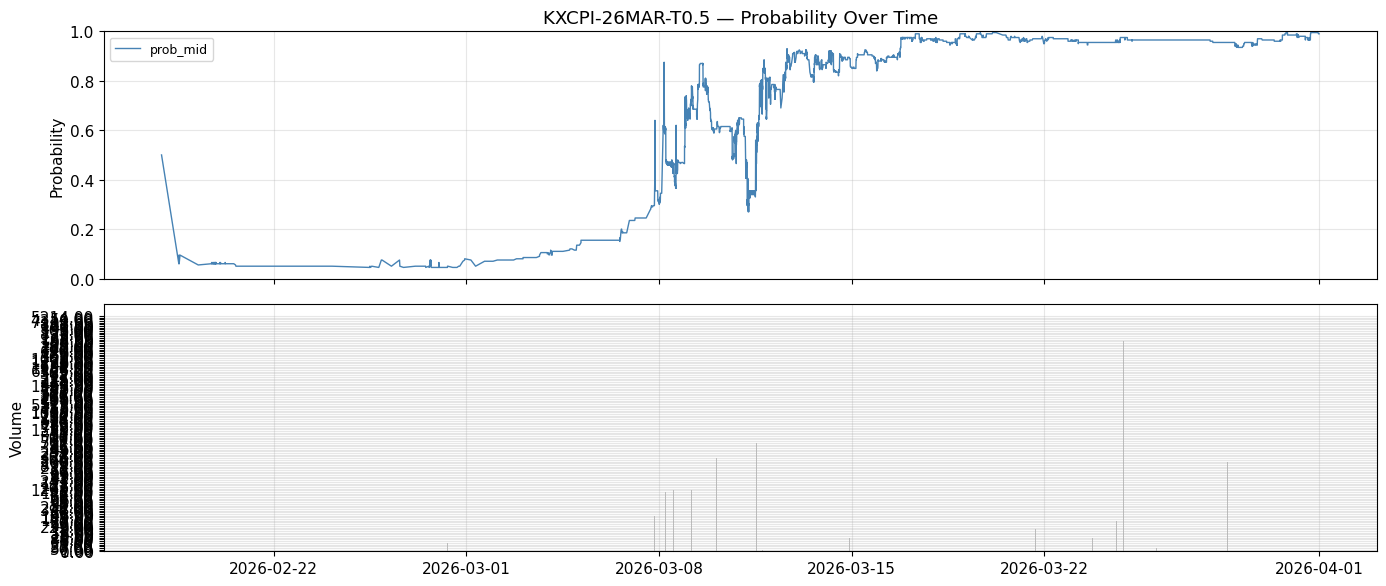

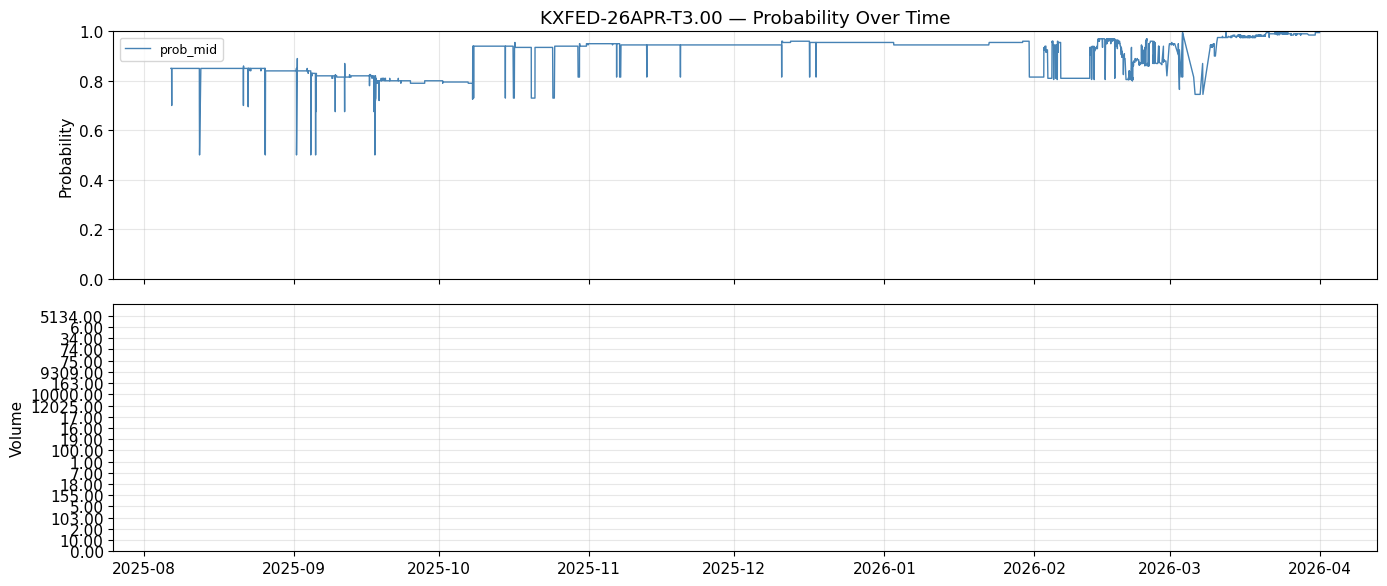

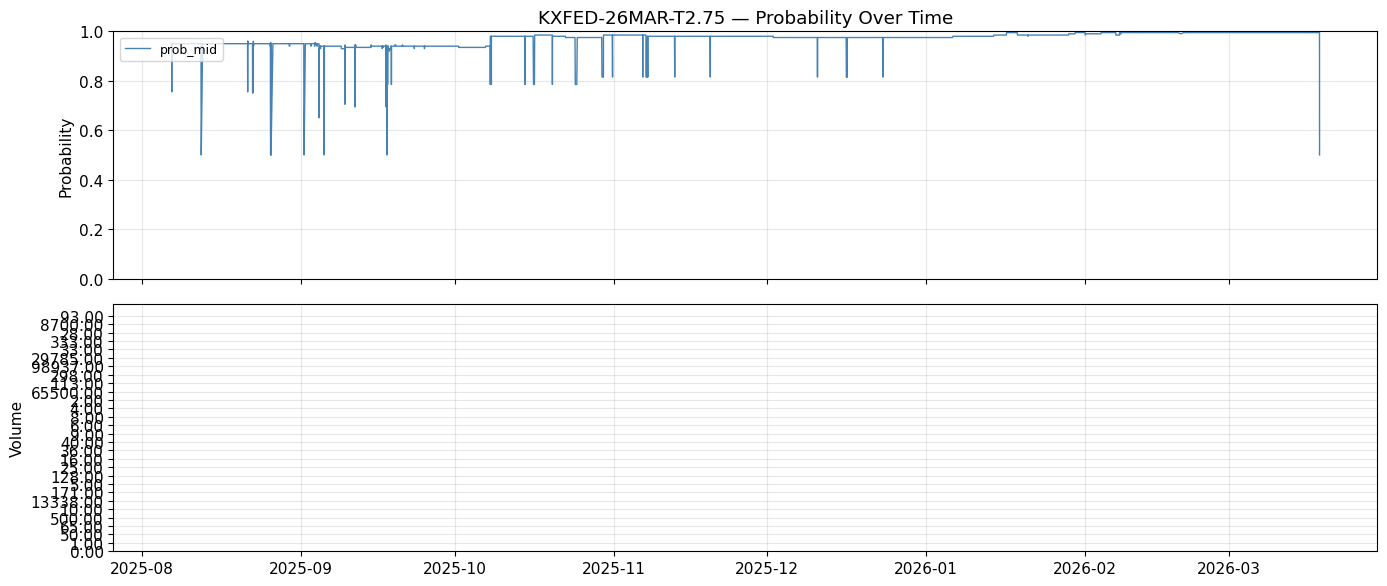

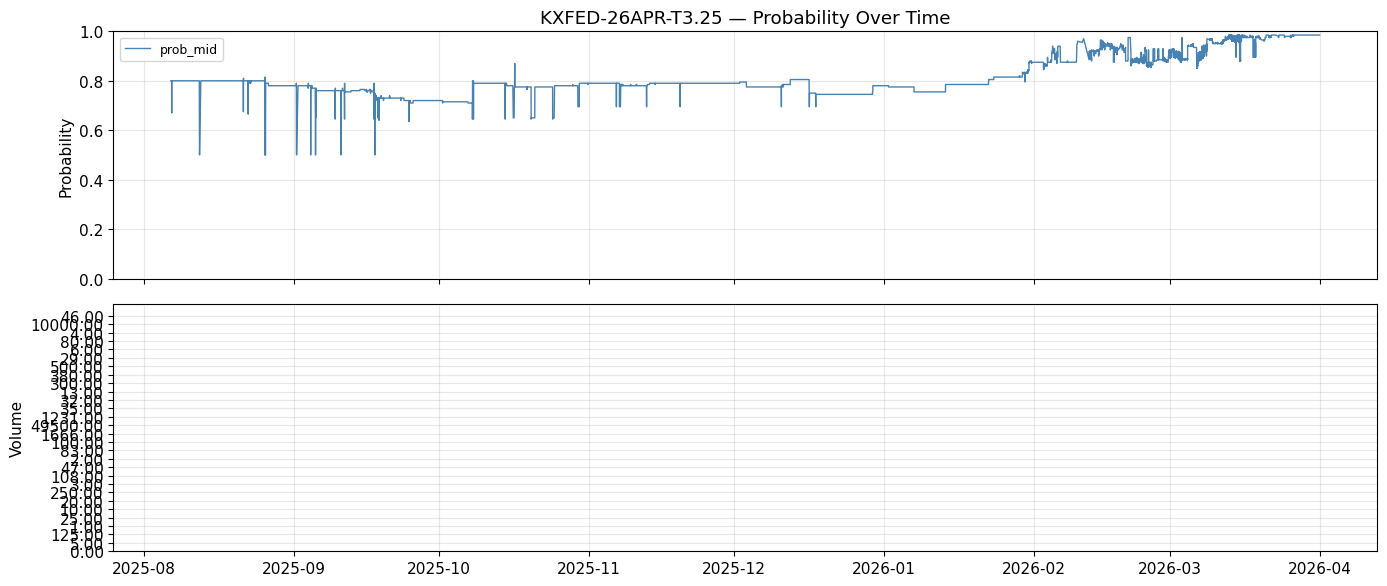

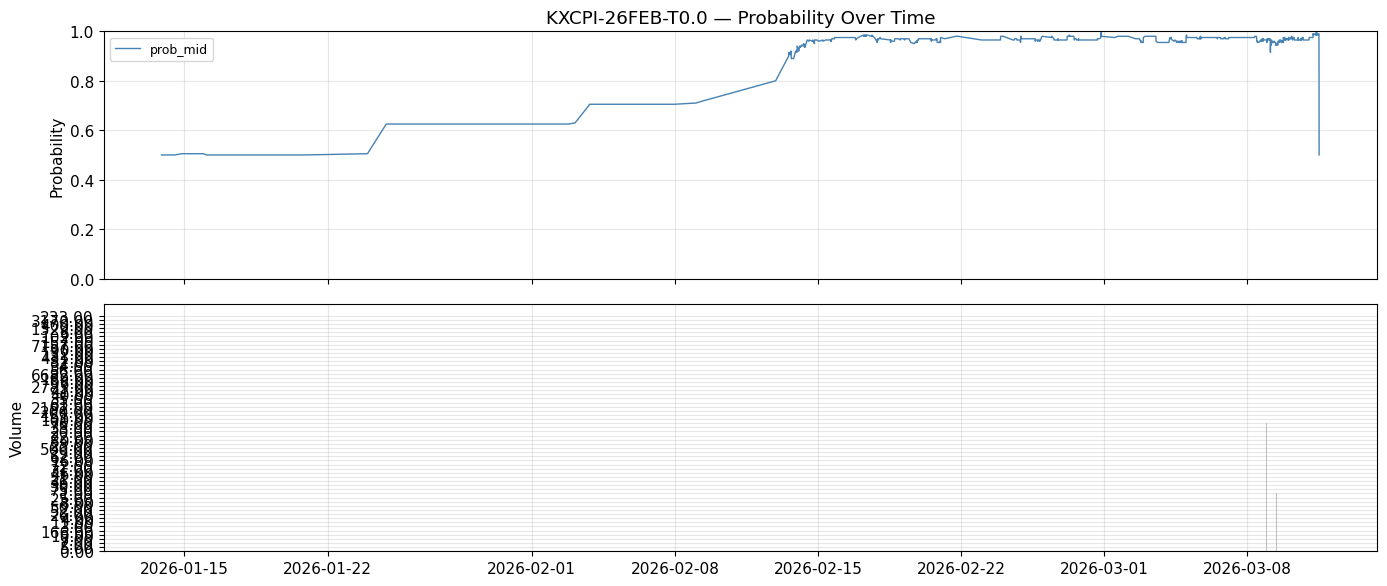

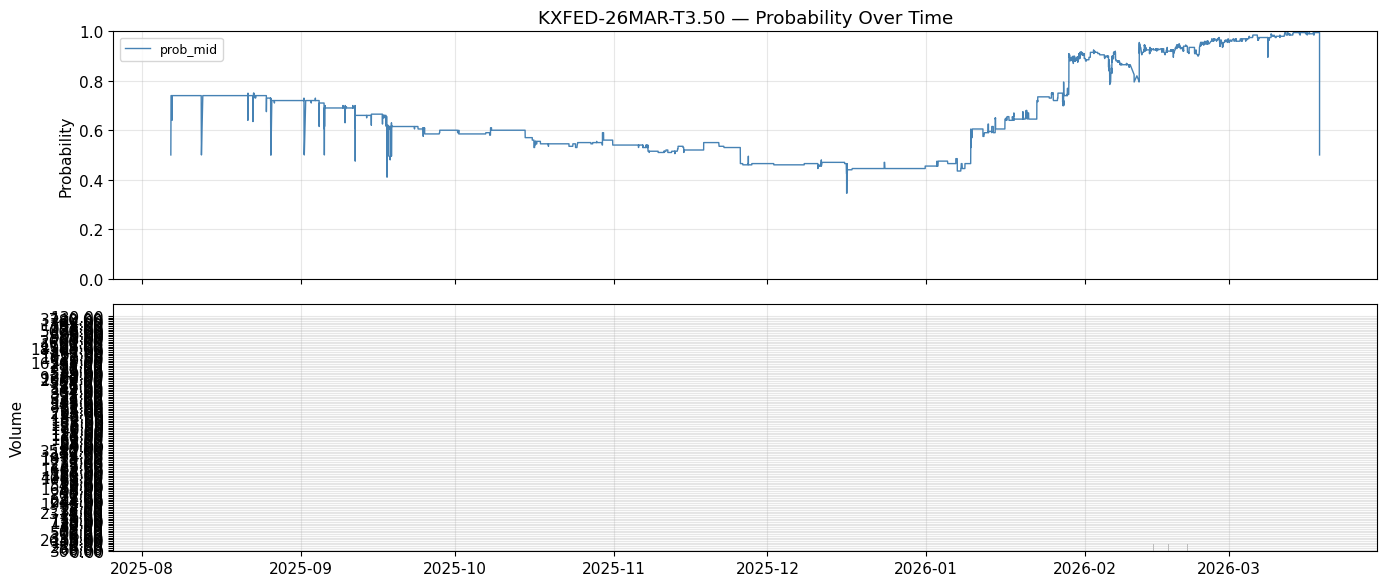

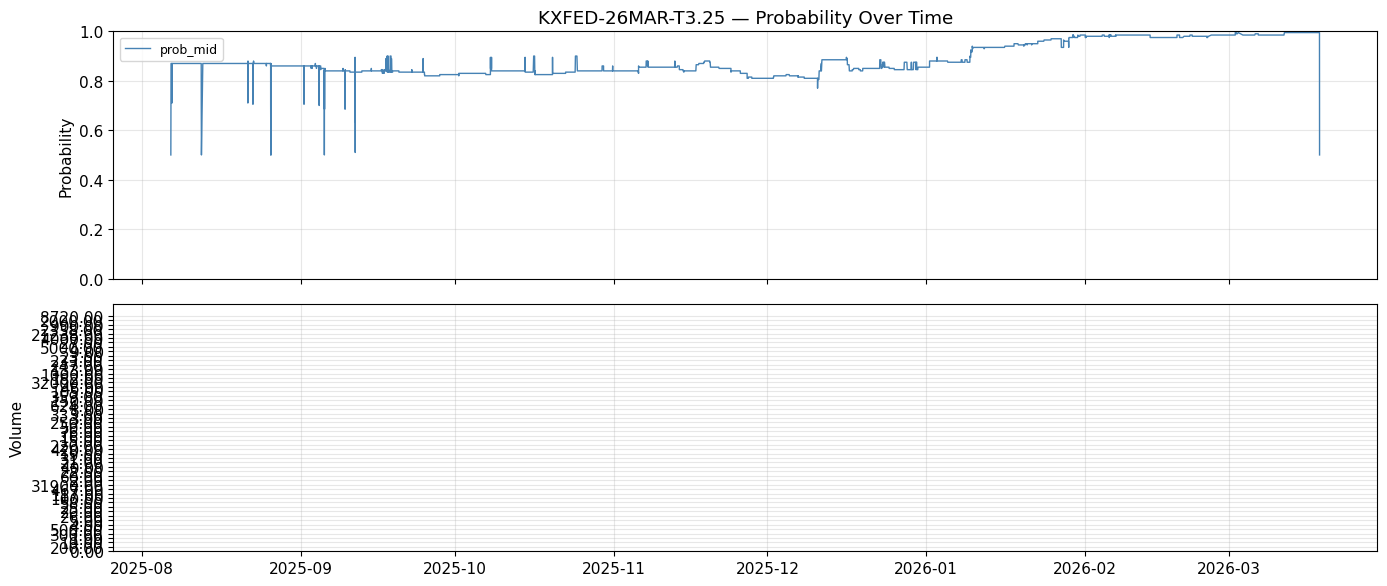

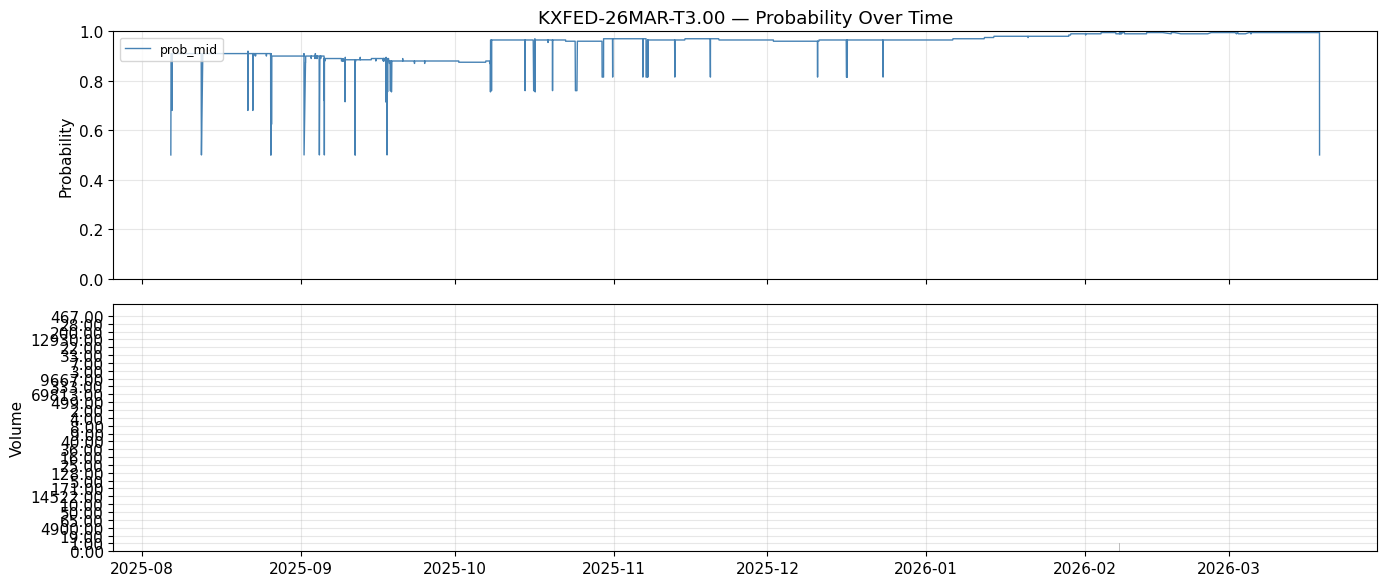

In [12]:
# Plot each prediction market's probability series
# Also load volume from individual parquet files

final_markets = pd.read_parquet('../data/raw/kalshi/final_market_list.parquet')
fig_dir = Path('../data/figures')
fig_dir.mkdir(parents=True, exist_ok=True)

for ticker in final_markets['ticker'].tolist():
    path = raw_dir / 'kalshi' / f'{ticker}.parquet'
    if not path.exists():
        continue
    df = pd.read_parquet(path).set_index('timestamp_utc').sort_index()
    if 'prob_mid' not in df.columns:
        continue

    vol = df.get('volume', None)
    fig = plot_probability_series(
        prob_mid=df['prob_mid'],
        volume=vol,
        title=f'{ticker} — Probability Over Time',
    )
    plt.savefig(fig_dir / f'kalshi_prob_{ticker}.png', dpi=150, bbox_inches='tight')
    plt.show()
    plt.close()


## 5. Sanity Check: Raw Correlation (Daily)

In [14]:
# Daily first difference of each prediction market vs daily BTC log return
# This is a rough sanity check only — not the signal

btc = pd.read_parquet(raw_dir / 'crypto' / 'crypto_1m_BTCUSDT.parquet')
btc = btc.set_index('timestamp_utc').sort_index()
btc_daily = btc['log_ret'].resample('1D').sum()

corr_rows = []
for ticker in prob_df.columns:
    daily_dp = prob_df[ticker].resample('1D').last().diff()
    aligned = pd.concat([daily_dp, btc_daily], axis=1).dropna()
    if len(aligned) < 20:
        continue
    r, p = stats_corr = __import__('scipy').stats.pearsonr(aligned.iloc[:,0], aligned.iloc[:,1])
    corr_rows.append({'ticker': ticker, 'pearson_r': round(r, 3), 'p_value': round(p, 4)})

corr_df = pd.DataFrame(corr_rows).sort_values('pearson_r', ascending=False)
print('Daily correlation: delta_prob vs BTC daily return')
print(corr_df.to_string(index=False))
print('\nNote: even weak positive correlations here suggest some information content.')
print('The actual signal analysis (CCF, Granger) is in notebook 04.')

Daily correlation: delta_prob vs BTC daily return
                          ticker  pearson_r  p_value
     KXBTCMAXY-26DEC31-109999.99      0.843   0.0000
              KXBTCMAX100-26-SEP      0.799   0.0000
      KXBTCMAXY-26DEC31-99999.99      0.780   0.0000
             KXBTCMAX100-26-JUNE      0.773   0.0000
              KXBTCMAX100-26-MAY      0.763   0.0000
     KXBTCMAXY-26DEC31-119999.99      0.762   0.0000
              KXBTCMAX100-26-DEC      0.758   0.0000
     KXBTCMAXY-26DEC31-149999.99      0.692   0.0000
     KXBTCMAXY-26DEC31-139999.99      0.691   0.0000
     KXBTCMAXY-26DEC31-129999.99      0.681   0.0000
              KXBTCMAX100-26-APR      0.610   0.0000
    KXBTCMAXY-25-DEC31-129999.99      0.568   0.0000
              KXBTCMAX100-26-MAR      0.477   0.0000
    KXBTCMAXY-25-DEC31-139999.99      0.465   0.0000
KXBTCMAX150-25-26MAR31-149999.99      0.353   0.0000
KXBTCMAX150-25-26APR30-149999.99      0.339   0.0000
KXBTCMAX150-25-26MAY31-149999.99      0.324   0.0